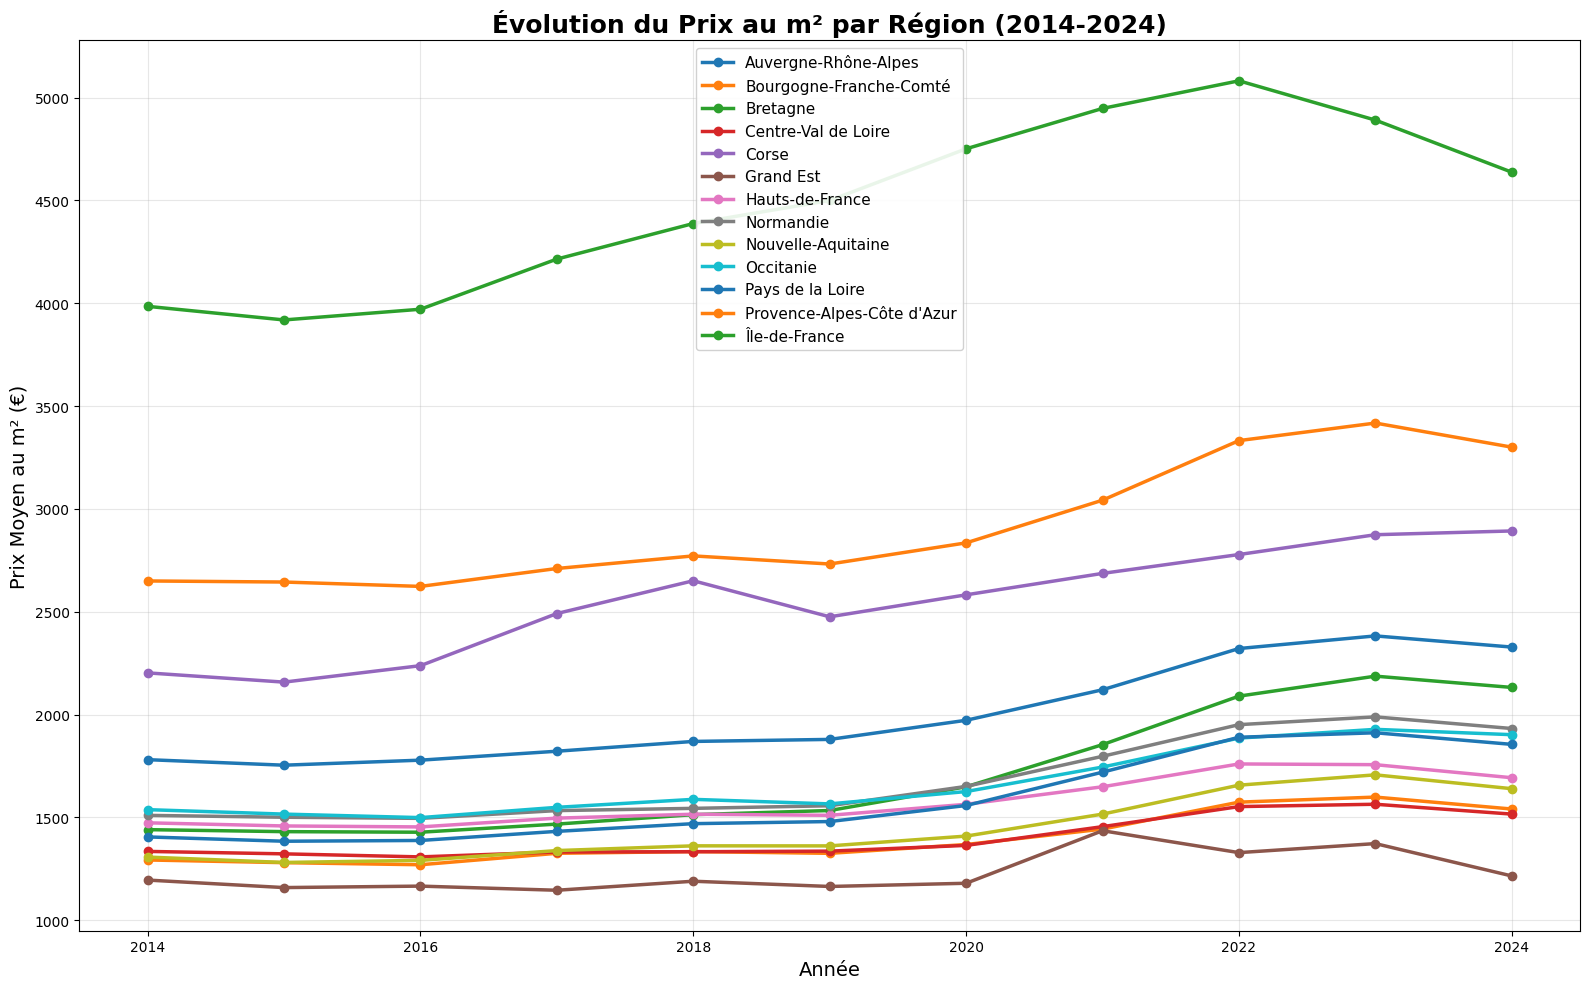

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Lire les données
df = pd.read_csv(r'C:\Users\Clement\OneDrive\Bureau\data imo\code\dvf.csv', sep=',')
df.columns = df.columns.str.strip()

# Extraire le code département (2 premiers chiffres du code INSEE)
df['Departement'] = df['INSEE_COM'].astype(str).str[:2]

# Dictionnaire des départements par région (France métropolitaine)
departements_regions = {
    'Auvergne-Rhône-Alpes': ['01', '03', '07', '15', '26', '38', '42', '43', '63', '69', '73', '74'],
    'Bourgogne-Franche-Comté': ['21', '25', '39', '58', '70', '71', '89', '90'],
    'Bretagne': ['22', '29', '35', '56'],
    'Centre-Val de Loire': ['18', '28', '36', '37', '41', '45'],
    'Corse': ['2A', '2B', '20'],
    'Grand Est': ['08', '10', '51', '52', '54', '55', '57', '67', '68', '88'],
    'Hauts-de-France': ['02', '59', '60', '62', '80'],
    'Île-de-France': ['75', '77', '78', '91', '92', '93', '94', '95'],
    'Normandie': ['14', '27', '50', '61', '76'],
    'Nouvelle-Aquitaine': ['16', '17', '19', '23', '24', '33', '40', '47', '64', '79', '86', '87'],
    'Occitanie': ['09', '11', '12', '30', '31', '32', '34', '46', '48', '65', '66', '81', '82'],
    'Pays de la Loire': ['44', '49', '53', '72', '85'],
    'Provence-Alpes-Côte d\'Azur': ['04', '05', '06', '13', '83', '84']
}

# Calculer les moyennes par département et par année
moyennes_dept = df.groupby(['Departement', 'annee']).agg({'Prixm2Moyen': 'mean'}).reset_index()

# Créer un dictionnaire inversé : département -> région
dept_vers_region = {dept: region for region, depts in departements_regions.items() for dept in depts}

# Ajouter la colonne région et supprimer les départements sans région (DOM-TOM)
moyennes_dept['Region'] = moyennes_dept['Departement'].map(dept_vers_region)
moyennes_dept = moyennes_dept[moyennes_dept['Region'].notna()]

# Calculer la moyenne par région
moyennes_region = moyennes_dept.groupby(['Region', 'annee']).agg({'Prixm2Moyen': 'mean'}).reset_index()

# Créer le graphique
plt.figure(figsize=(16, 10))
for region in sorted(moyennes_region['Region'].unique()):
    data_region = moyennes_region[moyennes_region['Region'] == region]
    plt.plot(data_region['annee'], data_region['Prixm2Moyen'], marker='o', linewidth=2.5, label=region)

plt.title('Évolution du Prix au m² par Région (2014-2024)', fontsize=18, fontweight='bold')
plt.xlabel('Année', fontsize=14)
plt.ylabel('Prix Moyen au m² (€)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=11, framealpha=0.9)
plt.tight_layout()
plt.show()

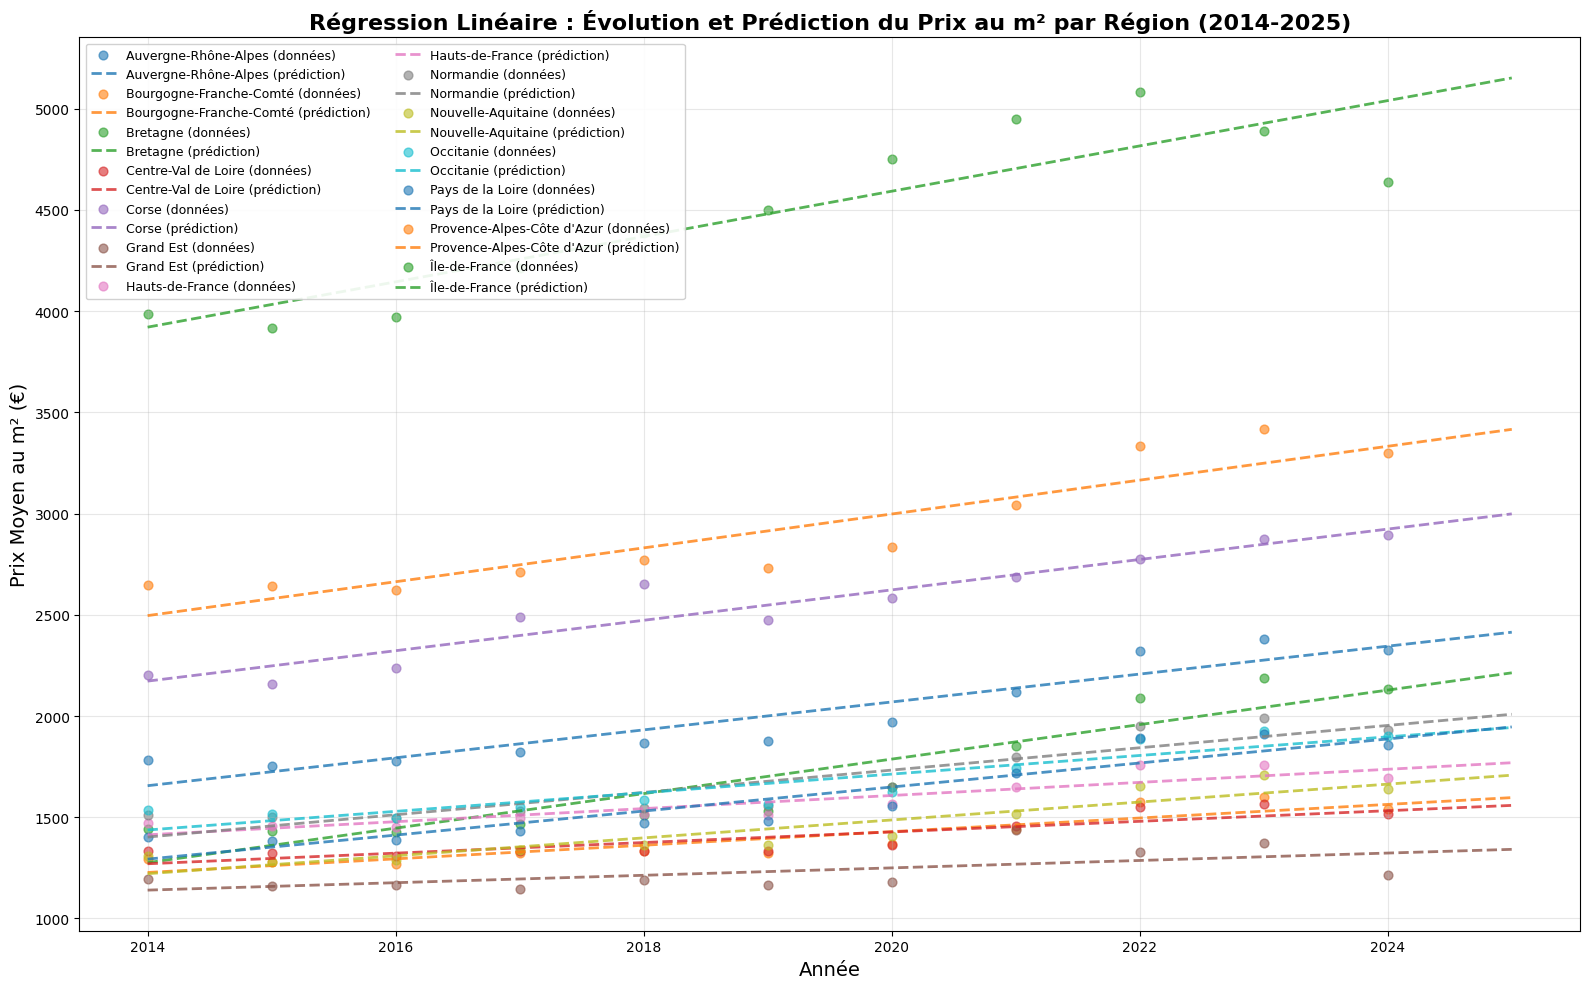


PRÉDICTIONS DU PRIX AU M² POUR 2025 PAR RÉGION (Régression Linéaire)
Île-de-France                       : 5,152.29 €/m²
Provence-Alpes-Côte d'Azur          : 3,416.32 €/m²
Corse                               : 2,998.80 €/m²
Auvergne-Rhône-Alpes                : 2,414.18 €/m²
Bretagne                            : 2,213.53 €/m²
Normandie                           : 2,008.82 €/m²
Pays de la Loire                    : 1,946.25 €/m²
Occitanie                           : 1,943.33 €/m²
Hauts-de-France                     : 1,769.44 €/m²
Nouvelle-Aquitaine                  : 1,707.89 €/m²
Bourgogne-Franche-Comté             : 1,597.11 €/m²
Centre-Val de Loire                 : 1,558.65 €/m²
Grand Est                           : 1,341.48 €/m²


In [6]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Créer un graphique pour les régressions linéaires
plt.figure(figsize=(16, 10))
predictions_2025 = {}

for region in sorted(moyennes_region['Region'].unique()):
    data_region = moyennes_region[moyennes_region['Region'] == region]
    
    X = data_region['annee'].values.reshape(-1, 1)
    y = data_region['Prixm2Moyen'].values
    
    model = LinearRegression()
    model.fit(X, y)
    
    annees_prediction = np.arange(2014, 2026).reshape(-1, 1)
    prix_prediction = model.predict(annees_prediction)
    predictions_2025[region] = prix_prediction[-1]
    
    plt.scatter(X, y, label=f'{region} (données)', s=40, alpha=0.6)
    plt.plot(annees_prediction, prix_prediction, linestyle='--', linewidth=2, 
             label=f'{region} (prédiction)', alpha=0.8)

plt.title('Régression Linéaire : Évolution et Prédiction du Prix au m² par Région (2014-2025)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Année', fontsize=14)
plt.ylabel('Prix Moyen au m² (€)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=9, ncol=2, framealpha=0.9)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("PRÉDICTIONS DU PRIX AU M² POUR 2025 PAR RÉGION (Régression Linéaire)")
print("="*80)
for region, prix in sorted(predictions_2025.items(), key=lambda x: x[1], reverse=True):
    print(f"{region:<35} : {prix:>8,.2f} €/m²")

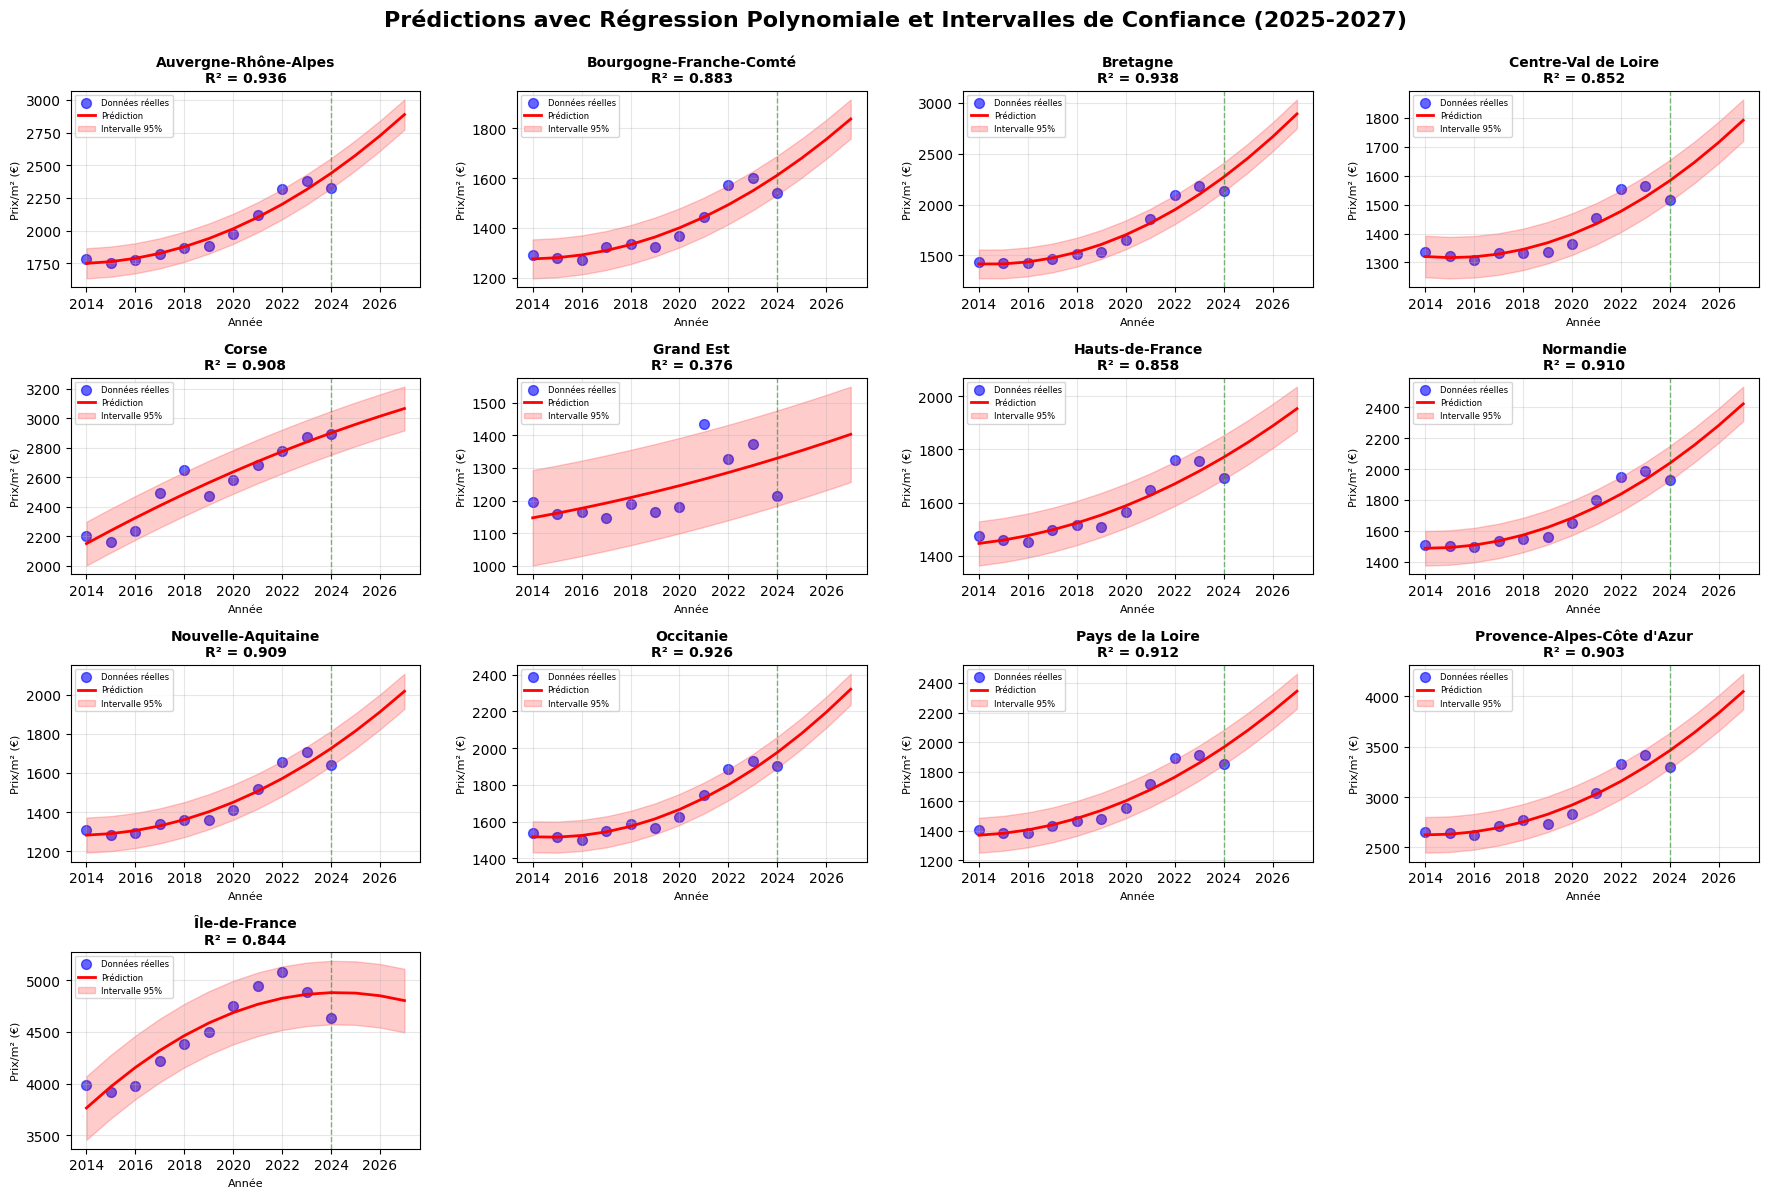


PRÉDICTIONS DU PRIX AU M² PAR RÉGION (2025-2027)
Région                         2025 (€/m²)     2026 (€/m²)     2027 (€/m²)     Incertitude (±) Qualité (R²)
----------------------------------------------------------------------------------------------------
Île-de-France                        4877            4851            4804      ±     308        0.844
Provence-Alpes-Côte d'Azur           3640            3835            4048      ±     177        0.903
Corse                                2959            3015            3067      ±     149        0.908
Auvergne-Rhône-Alpes                 2576            2726            2888      ±     115        0.936
Bretagne                             2458            2665            2891      ±     142        0.938
Normandie                            2155            2283            2423      ±     112        0.910
Occitanie                            2081            2196            2321      ±      85        0.926
Pays de la Loire           

In [7]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

plt.figure(figsize=(18, 12))
predictions_detaillees = {}
annees_futures = np.arange(2014, 2028).reshape(-1, 1)

for i, region in enumerate(sorted(moyennes_region['Region'].unique()), 1):
    data_region = moyennes_region[moyennes_region['Region'] == region]
    
    X = data_region['annee'].values.reshape(-1, 1)
    y = data_region['Prixm2Moyen'].values
    
    poly_features = PolynomialFeatures(degree=2)
    X_poly = poly_features.fit_transform(X)
    
    model_poly = LinearRegression()
    model_poly.fit(X_poly, y)
    
    X_futures_poly = poly_features.transform(annees_futures)
    predictions_poly = model_poly.predict(X_futures_poly)
    
    y_pred_train = model_poly.predict(X_poly)
    std_residus = np.std(y - y_pred_train)
    marge_erreur = 1.96 * std_residus
    
    predictions_detaillees[region] = {
        '2025': predictions_poly[11],
        '2026': predictions_poly[12],
        '2027': predictions_poly[13],
        'incertitude': marge_erreur,
        'r2_score': r2_score(y, y_pred_train)
    }
    
    plt.subplot(4, 4, i)
    plt.scatter(X, y, color='blue', s=50, alpha=0.6, label='Données réelles')
    plt.plot(annees_futures, predictions_poly, 'r-', linewidth=2, label='Prédiction')
    plt.fill_between(annees_futures.flatten(), predictions_poly - marge_erreur, 
                     predictions_poly + marge_erreur, alpha=0.2, color='red', label='Intervalle 95%')
    plt.axvline(x=2024, color='green', linestyle='--', linewidth=1, alpha=0.5)
    
    plt.title(f'{region}\nR² = {predictions_detaillees[region]["r2_score"]:.3f}', 
              fontsize=10, fontweight='bold')
    plt.xlabel('Année', fontsize=8)
    plt.ylabel('Prix/m² (€)', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=6, loc='best')

plt.suptitle('Prédictions avec Régression Polynomiale et Intervalles de Confiance (2025-2027)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n" + "="*100)
print("PRÉDICTIONS DU PRIX AU M² PAR RÉGION (2025-2027)")
print("="*100)
print(f"{'Région':<30} {'2025 (€/m²)':<15} {'2026 (€/m²)':<15} {'2027 (€/m²)':<15} {'Incertitude (±)':<15} {'Qualité (R²)':<12}")
print("-"*100)

for region, preds in sorted(predictions_detaillees.items(), key=lambda x: x[1]['2025'], reverse=True):
    print(f"{region:<30} {preds['2025']:>10.0f}      {preds['2026']:>10.0f}      "
          f"{preds['2027']:>10.0f}      ±{preds['incertitude']:>8.0f}       {preds['r2_score']:>6.3f}")

print("="*100)

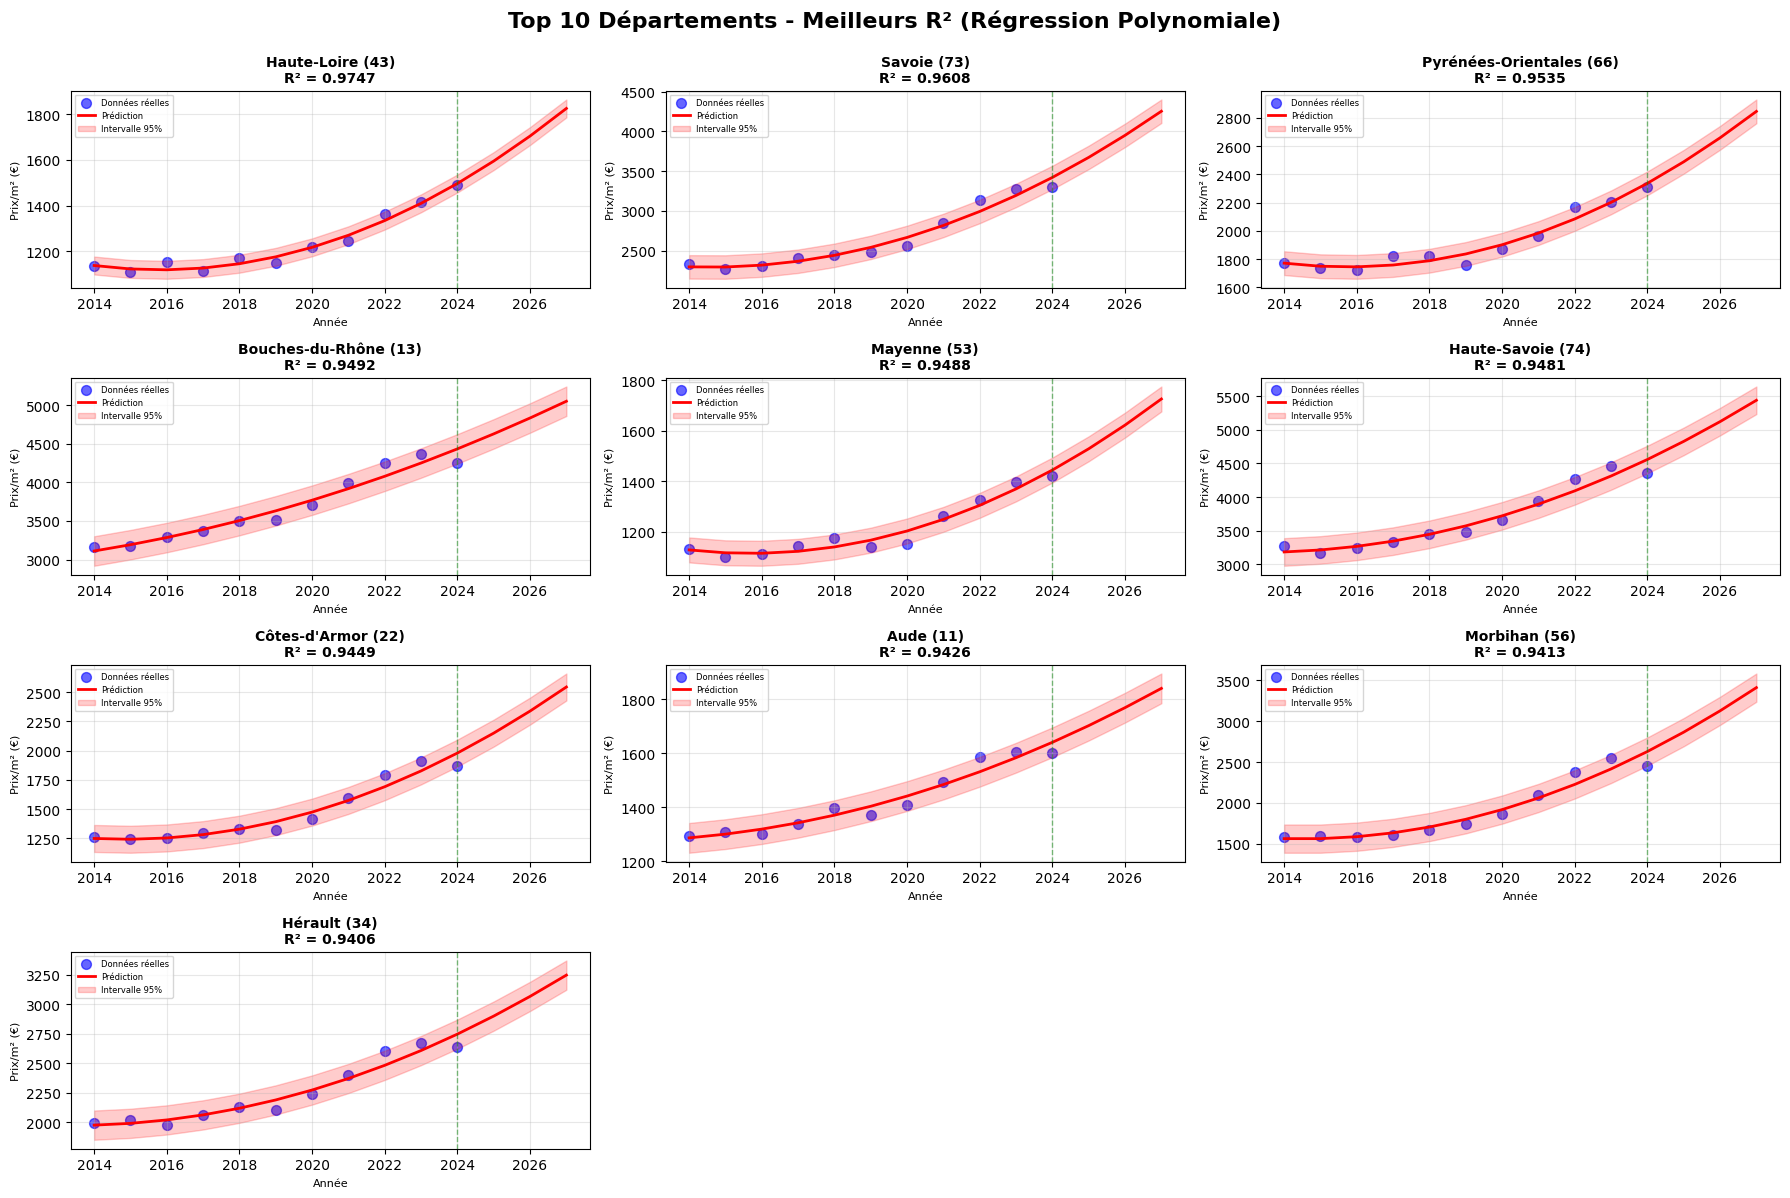


TOP 10 DÉPARTEMENTS - PRÉDICTIONS DU PRIX AU M² (2025-2027) - TRIÉS PAR QUALITÉ DU MODÈLE
Rang   Département                    2025 (€/m²)     2026 (€/m²)     2027 (€/m²)     Incertitude (±)    R² (Qualité)
-----------------------------------------------------------------------------------------------------------------------------
1      Haute-Loire (43)                     1595            1704            1825      ±      39              0.9747
2      Savoie (73)                          3674            3952            4255      ±     148              0.9608
3      Pyrénées-Orientales (66)             2490            2659            2847      ±      84              0.9535
4      Bouches-du-Rhône (13)                4628            4833            5050      ±     191              0.9492
5      Mayenne (53)                         1529            1622            1726      ±      50              0.9488
6      Haute-Savoie (74)                    4829            5122            5439     

In [8]:
noms_departements = {
    '01': 'Ain', '02': 'Aisne', '03': 'Allier', '04': 'Alpes-de-Haute-Provence', '05': 'Hautes-Alpes',
    '06': 'Alpes-Maritimes', '07': 'Ardèche', '08': 'Ardennes', '09': 'Ariège', '10': 'Aube',
    '11': 'Aude', '12': 'Aveyron', '13': 'Bouches-du-Rhône', '14': 'Calvados', '15': 'Cantal',
    '16': 'Charente', '17': 'Charente-Maritime', '18': 'Cher', '19': 'Corrèze', '21': 'Côte-d\'Or',
    '22': 'Côtes-d\'Armor', '23': 'Creuse', '24': 'Dordogne', '25': 'Doubs', '26': 'Drôme',
    '27': 'Eure', '28': 'Eure-et-Loir', '29': 'Finistère', '30': 'Gard', '31': 'Haute-Garonne',
    '32': 'Gers', '33': 'Gironde', '34': 'Hérault', '35': 'Ille-et-Vilaine', '36': 'Indre',
    '37': 'Indre-et-Loire', '38': 'Isère', '39': 'Jura', '40': 'Landes', '41': 'Loir-et-Cher',
    '42': 'Loire', '43': 'Haute-Loire', '44': 'Loire-Atlantique', '45': 'Loiret', '46': 'Lot',
    '47': 'Lot-et-Garonne', '48': 'Lozère', '49': 'Maine-et-Loire', '50': 'Manche', '51': 'Marne',
    '52': 'Haute-Marne', '53': 'Mayenne', '54': 'Meurthe-et-Moselle', '55': 'Meuse', '56': 'Morbihan',
    '57': 'Moselle', '58': 'Nièvre', '59': 'Nord', '60': 'Oise', '61': 'Orne',
    '62': 'Pas-de-Calais', '63': 'Puy-de-Dôme', '64': 'Pyrénées-Atlantiques', '65': 'Hautes-Pyrénées',
    '66': 'Pyrénées-Orientales', '67': 'Bas-Rhin', '68': 'Haut-Rhin', '69': 'Rhône', '70': 'Haute-Saône',
    '71': 'Saône-et-Loire', '72': 'Sarthe', '73': 'Savoie', '74': 'Haute-Savoie', '75': 'Paris',
    '76': 'Seine-Maritime', '77': 'Seine-et-Marne', '78': 'Yvelines', '79': 'Deux-Sèvres', '80': 'Somme',
    '81': 'Tarn', '82': 'Tarn-et-Garonne', '83': 'Var', '84': 'Vaucluse', '85': 'Vendée',
    '86': 'Vienne', '87': 'Haute-Vienne', '88': 'Vosges', '89': 'Yonne', '90': 'Territoire de Belfort',
    '91': 'Essonne', '92': 'Hauts-de-Seine', '93': 'Seine-Saint-Denis', '94': 'Val-de-Marne', '95': 'Val-d\'Oise'
}

plt.figure(figsize=(18, 12))
predictions_dept = {}
annees_futures = np.arange(2014, 2028).reshape(-1, 1)

for dept in moyennes_dept['Departement'].unique():
    data_dept = moyennes_dept[moyennes_dept['Departement'] == dept]
    if len(data_dept) < 3:
        continue
    
    X = data_dept['annee'].values.reshape(-1, 1)
    y = data_dept['Prixm2Moyen'].values
    
    poly_features = PolynomialFeatures(degree=2)
    X_poly = poly_features.fit_transform(X)
    model_poly = LinearRegression()
    model_poly.fit(X_poly, y)
    
    X_futures_poly = poly_features.transform(annees_futures)
    predictions_poly = model_poly.predict(X_futures_poly)
    
    y_pred_train = model_poly.predict(X_poly)
    std_residus = np.std(y - y_pred_train)
    marge_erreur = 1.96 * std_residus
    r2 = r2_score(y, y_pred_train)
    
    predictions_dept[dept] = {
        '2025': predictions_poly[11],
        '2026': predictions_poly[12],
        '2027': predictions_poly[13],
        'incertitude': marge_erreur,
        'r2_score': r2,
        'X': X,
        'y': y,
        'predictions_poly': predictions_poly,
        'predictions_min': predictions_poly - marge_erreur,
        'predictions_max': predictions_poly + marge_erreur
    }

top_10_depts = sorted(predictions_dept.items(), key=lambda x: x[1]['r2_score'], reverse=True)[:10]

for i, (dept, preds) in enumerate(top_10_depts, 1):
    plt.subplot(4, 3, i)
    plt.scatter(preds['X'], preds['y'], color='blue', s=50, alpha=0.6, label='Données réelles')
    plt.plot(annees_futures, preds['predictions_poly'], 'r-', linewidth=2, label='Prédiction')
    plt.fill_between(annees_futures.flatten(), preds['predictions_min'], preds['predictions_max'], 
                     alpha=0.2, color='red', label='Intervalle 95%')
    plt.axvline(x=2024, color='green', linestyle='--', linewidth=1, alpha=0.5)
    
    nom_dept = noms_departements.get(dept, f'Dept {dept}')
    plt.title(f'{nom_dept} ({dept})\nR² = {preds["r2_score"]:.4f}', fontsize=10, fontweight='bold')
    plt.xlabel('Année', fontsize=8)
    plt.ylabel('Prix/m² (€)', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=6, loc='best')

plt.suptitle('Top 10 Départements - Meilleurs R² (Régression Polynomiale)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n" + "="*125)
print("TOP 10 DÉPARTEMENTS - PRÉDICTIONS DU PRIX AU M² (2025-2027) - TRIÉS PAR QUALITÉ DU MODÈLE")
print("="*125)
print(f"{'Rang':<6} {'Département':<30} {'2025 (€/m²)':<15} {'2026 (€/m²)':<15} {'2027 (€/m²)':<15} {'Incertitude (±)':<18} {'R² (Qualité)':<12}")
print("-"*125)

for i, (dept, preds) in enumerate(top_10_depts, 1):
    nom_dept = noms_departements.get(dept, f'Département {dept}')
    dept_nom_complet = f"{nom_dept} ({dept})"
    print(f"{i:<6} {dept_nom_complet:<30} {preds['2025']:>10.0f}      {preds['2026']:>10.0f}      "
          f"{preds['2027']:>10.0f}      ±{preds['incertitude']:>8.0f}            {preds['r2_score']:>8.4f}")

print("="*125)


📈 CRITÈRES : R² minimum = 0.85 | Départements fiables = 59



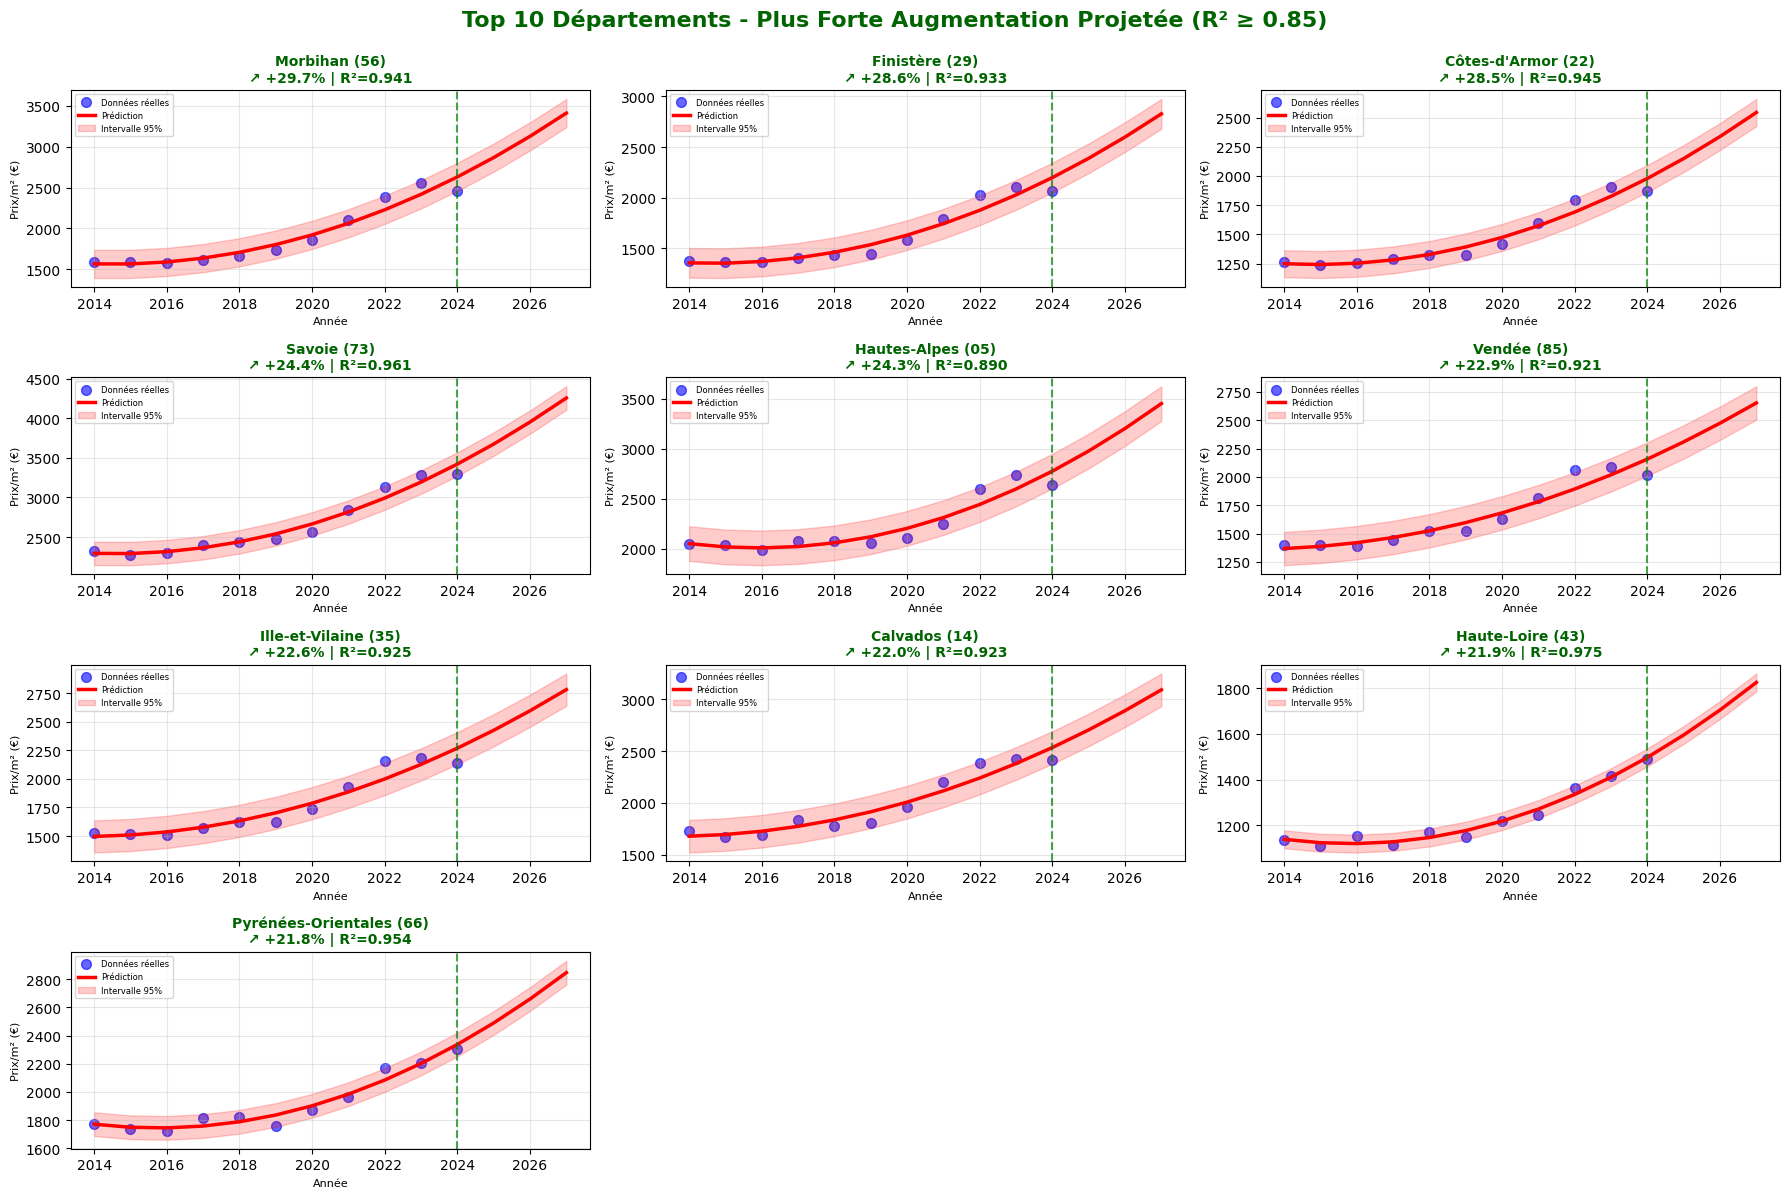


TOP 10 DÉPARTEMENTS - PLUS FORTE AUGMENTATION PROJETÉE DU PRIX AU M² (2024-2027)
Rang   Département                    Prix 2024    Prix 2027    Augmentation    % Hausse     Incertitude     R²        
-------------------------------------------------------------------------------------------------------------------------------------------------
1      Morbihan (56)                      2630 €/m²      3412 €/m²  +     782 €/m²   +  29.7 %     ±   173 €/m²      0.9413
2      Finistère (29)                     2199 €/m²      2828 €/m²  +     629 €/m²   +  28.6 %     ±   146 €/m²      0.9333
3      Côtes-d'Armor (22)                 1979 €/m²      2543 €/m²  +     564 €/m²   +  28.5 %     ±   115 €/m²      0.9449
4      Savoie (73)                        3421 €/m²      4255 €/m²  +     834 €/m²   +  24.4 %     ±   148 €/m²      0.9608
5      Hautes-Alpes (05)                  2775 €/m²      3450 €/m²  +     675 €/m²   +  24.3 %     ±   173 €/m²      0.8898
6      Vendée (85)              

In [9]:
plt.figure(figsize=(18, 12))
predictions_augmentation = {}

for dept in moyennes_dept['Departement'].unique():
    data_dept = moyennes_dept[moyennes_dept['Departement'] == dept]
    if len(data_dept) < 3:
        continue
    
    X = data_dept['annee'].values.reshape(-1, 1)
    y = data_dept['Prixm2Moyen'].values
    
    poly_features = PolynomialFeatures(degree=2)
    X_poly = poly_features.fit_transform(X)
    model_poly = LinearRegression()
    model_poly.fit(X_poly, y)
    
    X_futures_poly = poly_features.transform(annees_futures)
    predictions_poly = model_poly.predict(X_futures_poly)
    
    y_pred_train = model_poly.predict(X_poly)
    std_residus = np.std(y - y_pred_train)
    marge_erreur = 1.96 * std_residus
    r2 = r2_score(y, y_pred_train)
    
    prix_2024 = predictions_poly[10]
    prix_2027 = predictions_poly[13]
    augmentation_absolue = prix_2027 - prix_2024
    augmentation_pourcentage = ((prix_2027 - prix_2024) / prix_2024) * 100
    
    predictions_augmentation[dept] = {
        '2025': predictions_poly[11],
        '2026': predictions_poly[12],
        '2027': predictions_poly[13],
        'prix_2024': prix_2024,
        'augmentation_absolue': augmentation_absolue,
        'augmentation_pourcentage': augmentation_pourcentage,
        'incertitude': marge_erreur,
        'r2_score': r2,
        'X': X,
        'y': y,
        'predictions_poly': predictions_poly,
        'predictions_min': predictions_poly - marge_erreur,
        'predictions_max': predictions_poly + marge_erreur
    }

depts_fiables = {k: v for k, v in predictions_augmentation.items() if v['r2_score'] >= 0.85}
top_10_augmentation = sorted(depts_fiables.items(), key=lambda x: x[1]['augmentation_pourcentage'], reverse=True)[:10]

print(f"\n📈 CRITÈRES : R² minimum = 0.85 | Départements fiables = {len(depts_fiables)}\n")

for i, (dept, preds) in enumerate(top_10_augmentation, 1):
    plt.subplot(4, 3, i)
    plt.scatter(preds['X'], preds['y'], color='blue', s=50, alpha=0.6, label='Données réelles')
    plt.plot(annees_futures, preds['predictions_poly'], 'r-', linewidth=2.5, label='Prédiction')
    plt.fill_between(annees_futures.flatten(), preds['predictions_min'], preds['predictions_max'], 
                     alpha=0.2, color='red', label='Intervalle 95%')
    plt.axvline(x=2024, color='green', linestyle='--', linewidth=1.5, alpha=0.7)
    
    nom_dept = noms_departements.get(dept, f'Dept {dept}')
    plt.title(f'{nom_dept} ({dept})\n↗ +{preds["augmentation_pourcentage"]:.1f}% | R²={preds["r2_score"]:.3f}', 
              fontsize=10, fontweight='bold', color='darkgreen')
    plt.xlabel('Année', fontsize=8)
    plt.ylabel('Prix/m² (€)', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=6, loc='best')

plt.suptitle('Top 10 Départements - Plus Forte Augmentation Projetée (R² ≥ 0.85)', 
             fontsize=16, fontweight='bold', y=0.995, color='darkgreen')
plt.tight_layout()
plt.show()

print("\n" + "="*145)
print("TOP 10 DÉPARTEMENTS - PLUS FORTE AUGMENTATION PROJETÉE DU PRIX AU M² (2024-2027)")
print("="*145)
print(f"{'Rang':<6} {'Département':<30} {'Prix 2024':<12} {'Prix 2027':<12} {'Augmentation':<15} {'% Hausse':<12} {'Incertitude':<15} {'R²':<10}")
print("-"*145)

for i, (dept, preds) in enumerate(top_10_augmentation, 1):
    nom_dept = noms_departements.get(dept, f'Département {dept}')
    dept_nom_complet = f"{nom_dept} ({dept})"
    print(f"{i:<6} {dept_nom_complet:<30} {preds['prix_2024']:>8.0f} €/m²  {preds['2027']:>8.0f} €/m²  "
          f"+{preds['augmentation_absolue']:>8.0f} €/m²   +{preds['augmentation_pourcentage']:>6.1f} %     "
          f"±{preds['incertitude']:>6.0f} €/m²      {preds['r2_score']:>6.4f}")

print("="*145)


📉 CRITÈRES : R² minimum = 0.85 | Départements fiables = 59



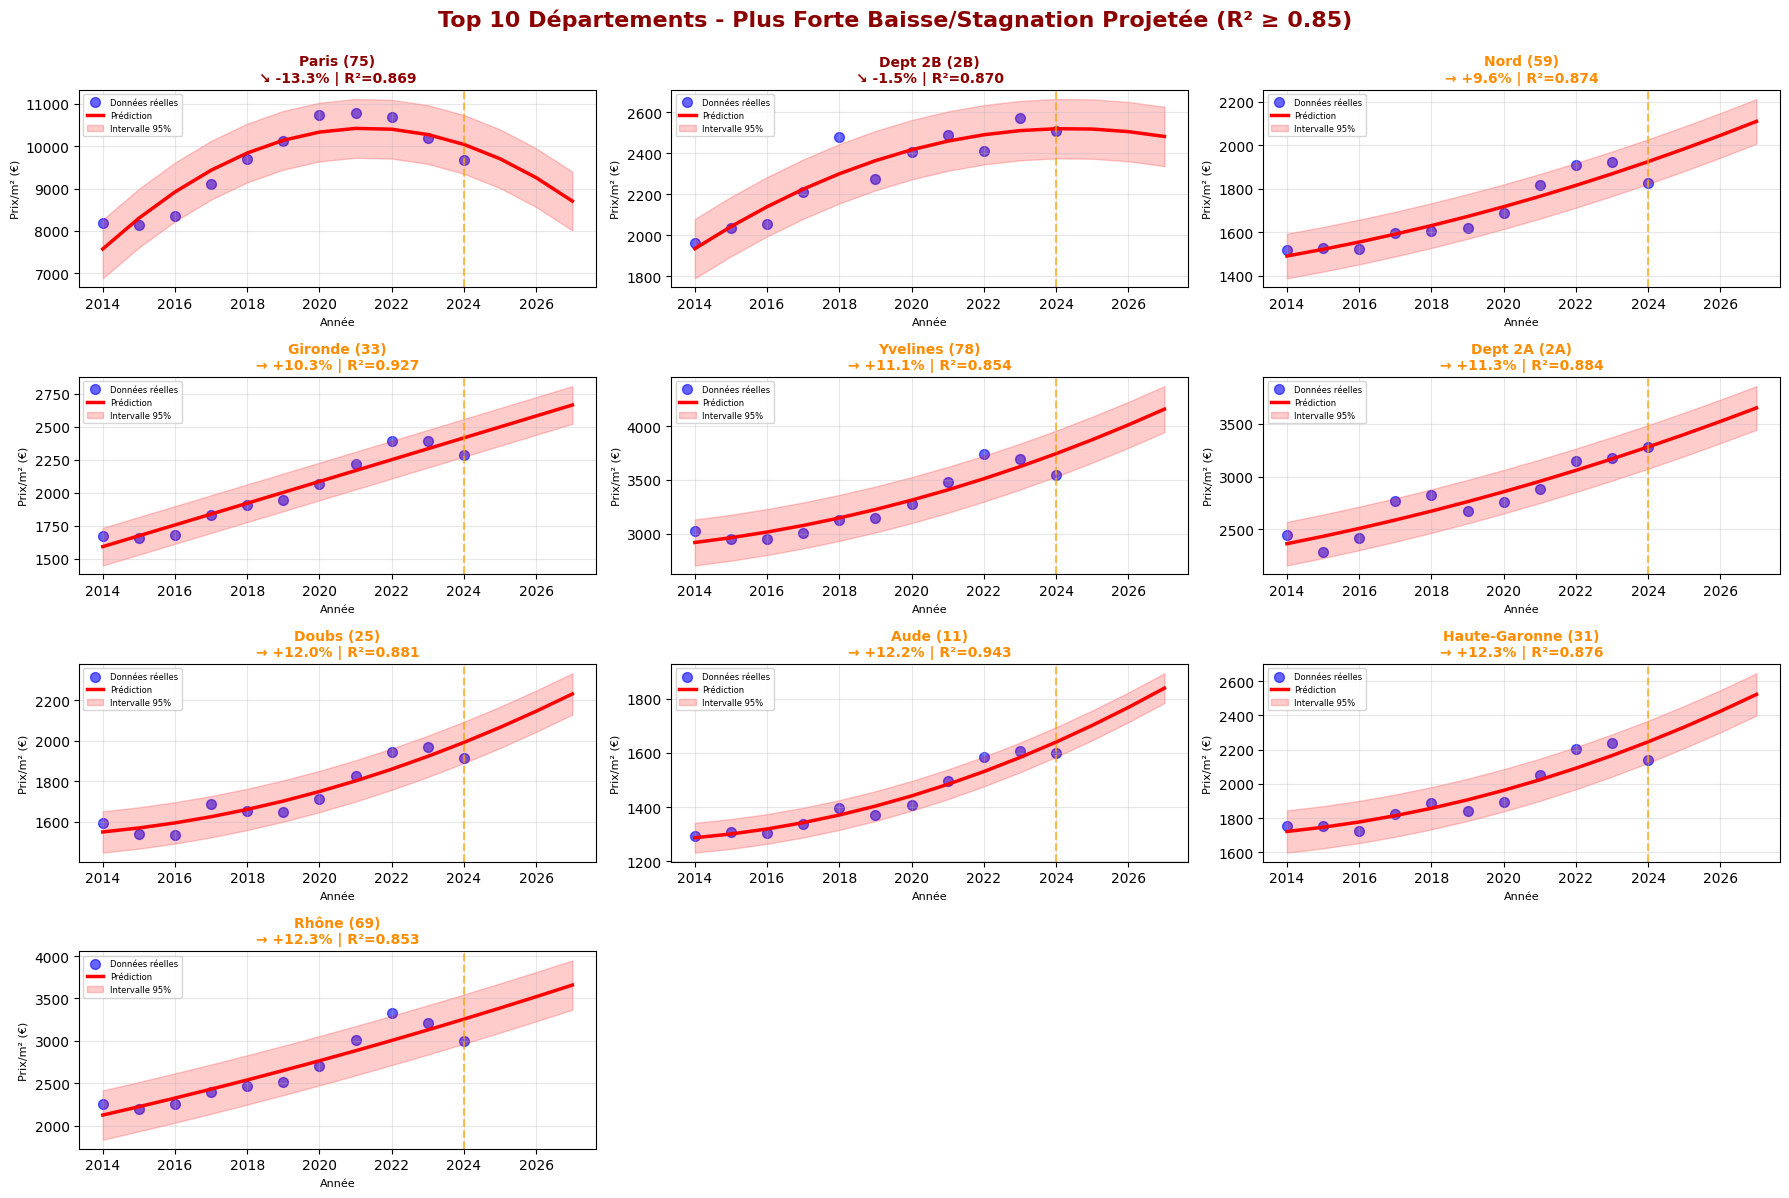


TOP 10 DÉPARTEMENTS - PLUS FORTE BAISSE/STAGNATION PROJETÉE DU PRIX AU M² (2024-2027)
Rang   Département                    Prix 2024    Prix 2027    Variation       % Évolution    Incertitude     R²        
-------------------------------------------------------------------------------------------------------------------------------------------------
1      Paris (75)                        10043 €/m²      8704 €/m²     -1339 €/m²    -13.3 %     ±   695 €/m²      0.8690
2      Département 2B (2B)                2520 €/m²      2482 €/m²       -38 €/m²     -1.5 %     ±   145 €/m²      0.8700
3      Nord (59)                          1925 €/m²      2110 €/m²  +     185 €/m²   +   9.6 %     ±   103 €/m²      0.8735
4      Gironde (33)                       2416 €/m²      2664 €/m²  +     249 €/m²   +  10.3 %     ±   143 €/m²      0.9274
5      Yvelines (78)                      3744 €/m²      4159 €/m²  +     414 €/m²   +  11.1 %     ±   214 €/m²      0.8538
6      Département 2A (2A)   

In [10]:
plt.figure(figsize=(18, 12))
predictions_baisse = {}

for dept in moyennes_dept['Departement'].unique():
    data_dept = moyennes_dept[moyennes_dept['Departement'] == dept]
    if len(data_dept) < 3:
        continue
    
    X = data_dept['annee'].values.reshape(-1, 1)
    y = data_dept['Prixm2Moyen'].values
    
    poly_features = PolynomialFeatures(degree=2)
    X_poly = poly_features.fit_transform(X)
    model_poly = LinearRegression()
    model_poly.fit(X_poly, y)
    
    X_futures_poly = poly_features.transform(annees_futures)
    predictions_poly = model_poly.predict(X_futures_poly)
    
    y_pred_train = model_poly.predict(X_poly)
    std_residus = np.std(y - y_pred_train)
    marge_erreur = 1.96 * std_residus
    r2 = r2_score(y, y_pred_train)
    
    prix_2024 = predictions_poly[10]
    prix_2027 = predictions_poly[13]
    variation_absolue = prix_2027 - prix_2024
    variation_pourcentage = ((prix_2027 - prix_2024) / prix_2024) * 100
    
    predictions_baisse[dept] = {
        '2025': predictions_poly[11],
        '2026': predictions_poly[12],
        '2027': predictions_poly[13],
        'prix_2024': prix_2024,
        'variation_absolue': variation_absolue,
        'variation_pourcentage': variation_pourcentage,
        'incertitude': marge_erreur,
        'r2_score': r2,
        'X': X,
        'y': y,
        'predictions_poly': predictions_poly,
        'predictions_min': predictions_poly - marge_erreur,
        'predictions_max': predictions_poly + marge_erreur
    }

depts_fiables = {k: v for k, v in predictions_baisse.items() if v['r2_score'] >= 0.85}
top_10_baisse = sorted(depts_fiables.items(), key=lambda x: x[1]['variation_pourcentage'], reverse=False)[:10]

print(f"\n📉 CRITÈRES : R² minimum = 0.85 | Départements fiables = {len(depts_fiables)}\n")

for i, (dept, preds) in enumerate(top_10_baisse, 1):
    plt.subplot(4, 3, i)
    plt.scatter(preds['X'], preds['y'], color='blue', s=50, alpha=0.6, label='Données réelles')
    plt.plot(annees_futures, preds['predictions_poly'], 'r-', linewidth=2.5, label='Prédiction')
    plt.fill_between(annees_futures.flatten(), preds['predictions_min'], preds['predictions_max'], 
                     alpha=0.2, color='red', label='Intervalle 95%')
    plt.axvline(x=2024, color='orange', linestyle='--', linewidth=1.5, alpha=0.7)
    
    nom_dept = noms_departements.get(dept, f'Dept {dept}')
    symbole = '↘' if preds['variation_pourcentage'] < 0 else '→'
    couleur = 'darkred' if preds['variation_pourcentage'] < 0 else 'darkorange'
    
    plt.title(f'{nom_dept} ({dept})\n{symbole} {preds["variation_pourcentage"]:+.1f}% | R²={preds["r2_score"]:.3f}', 
              fontsize=10, fontweight='bold', color=couleur)
    plt.xlabel('Année', fontsize=8)
    plt.ylabel('Prix/m² (€)', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=6, loc='best')

plt.suptitle('Top 10 Départements - Plus Forte Baisse/Stagnation Projetée (R² ≥ 0.85)', 
             fontsize=16, fontweight='bold', y=0.995, color='darkred')
plt.tight_layout()
plt.show()

print("\n" + "="*145)
print("TOP 10 DÉPARTEMENTS - PLUS FORTE BAISSE/STAGNATION PROJETÉE DU PRIX AU M² (2024-2027)")
print("="*145)
print(f"{'Rang':<6} {'Département':<30} {'Prix 2024':<12} {'Prix 2027':<12} {'Variation':<15} {'% Évolution':<14} {'Incertitude':<15} {'R²':<10}")
print("-"*145)

for i, (dept, preds) in enumerate(top_10_baisse, 1):
    nom_dept = noms_departements.get(dept, f'Département {dept}')
    dept_nom_complet = f"{nom_dept} ({dept})"
    variation_sign = '+' if preds['variation_absolue'] >= 0 else ''
    pourcent_sign = '+' if preds['variation_pourcentage'] >= 0 else ''
    
    print(f"{i:<6} {dept_nom_complet:<30} {preds['prix_2024']:>8.0f} €/m²  {preds['2027']:>8.0f} €/m²  "
          f"{variation_sign}{preds['variation_absolue']:>8.0f} €/m²   {pourcent_sign}{preds['variation_pourcentage']:>6.1f} %     "
          f"±{preds['incertitude']:>6.0f} €/m²      {preds['r2_score']:>6.4f}")

print("="*145)

🔍 ÉTAPE 1 : Identification des 10 départements à plus fort potentiel d'augmentation

Départements sélectionnés : 56, 29, 22, 73, 05, 85, 35, 14, 43, 66

🏙️ ÉTAPE 2 : Analyse des villes dans ces départements

Départements sélectionnés : 56, 29, 22, 73, 05, 85, 35, 14, 43, 66

🏙️ ÉTAPE 2 : Analyse des villes dans ces départements

Villes analysées : 2881
Villes fiables (R² ≥ 0.90) : 303

📊 ÉTAPE 3 : Visualisation des 10 meilleures villes

Villes analysées : 2881
Villes fiables (R² ≥ 0.90) : 303

📊 ÉTAPE 3 : Visualisation des 10 meilleures villes



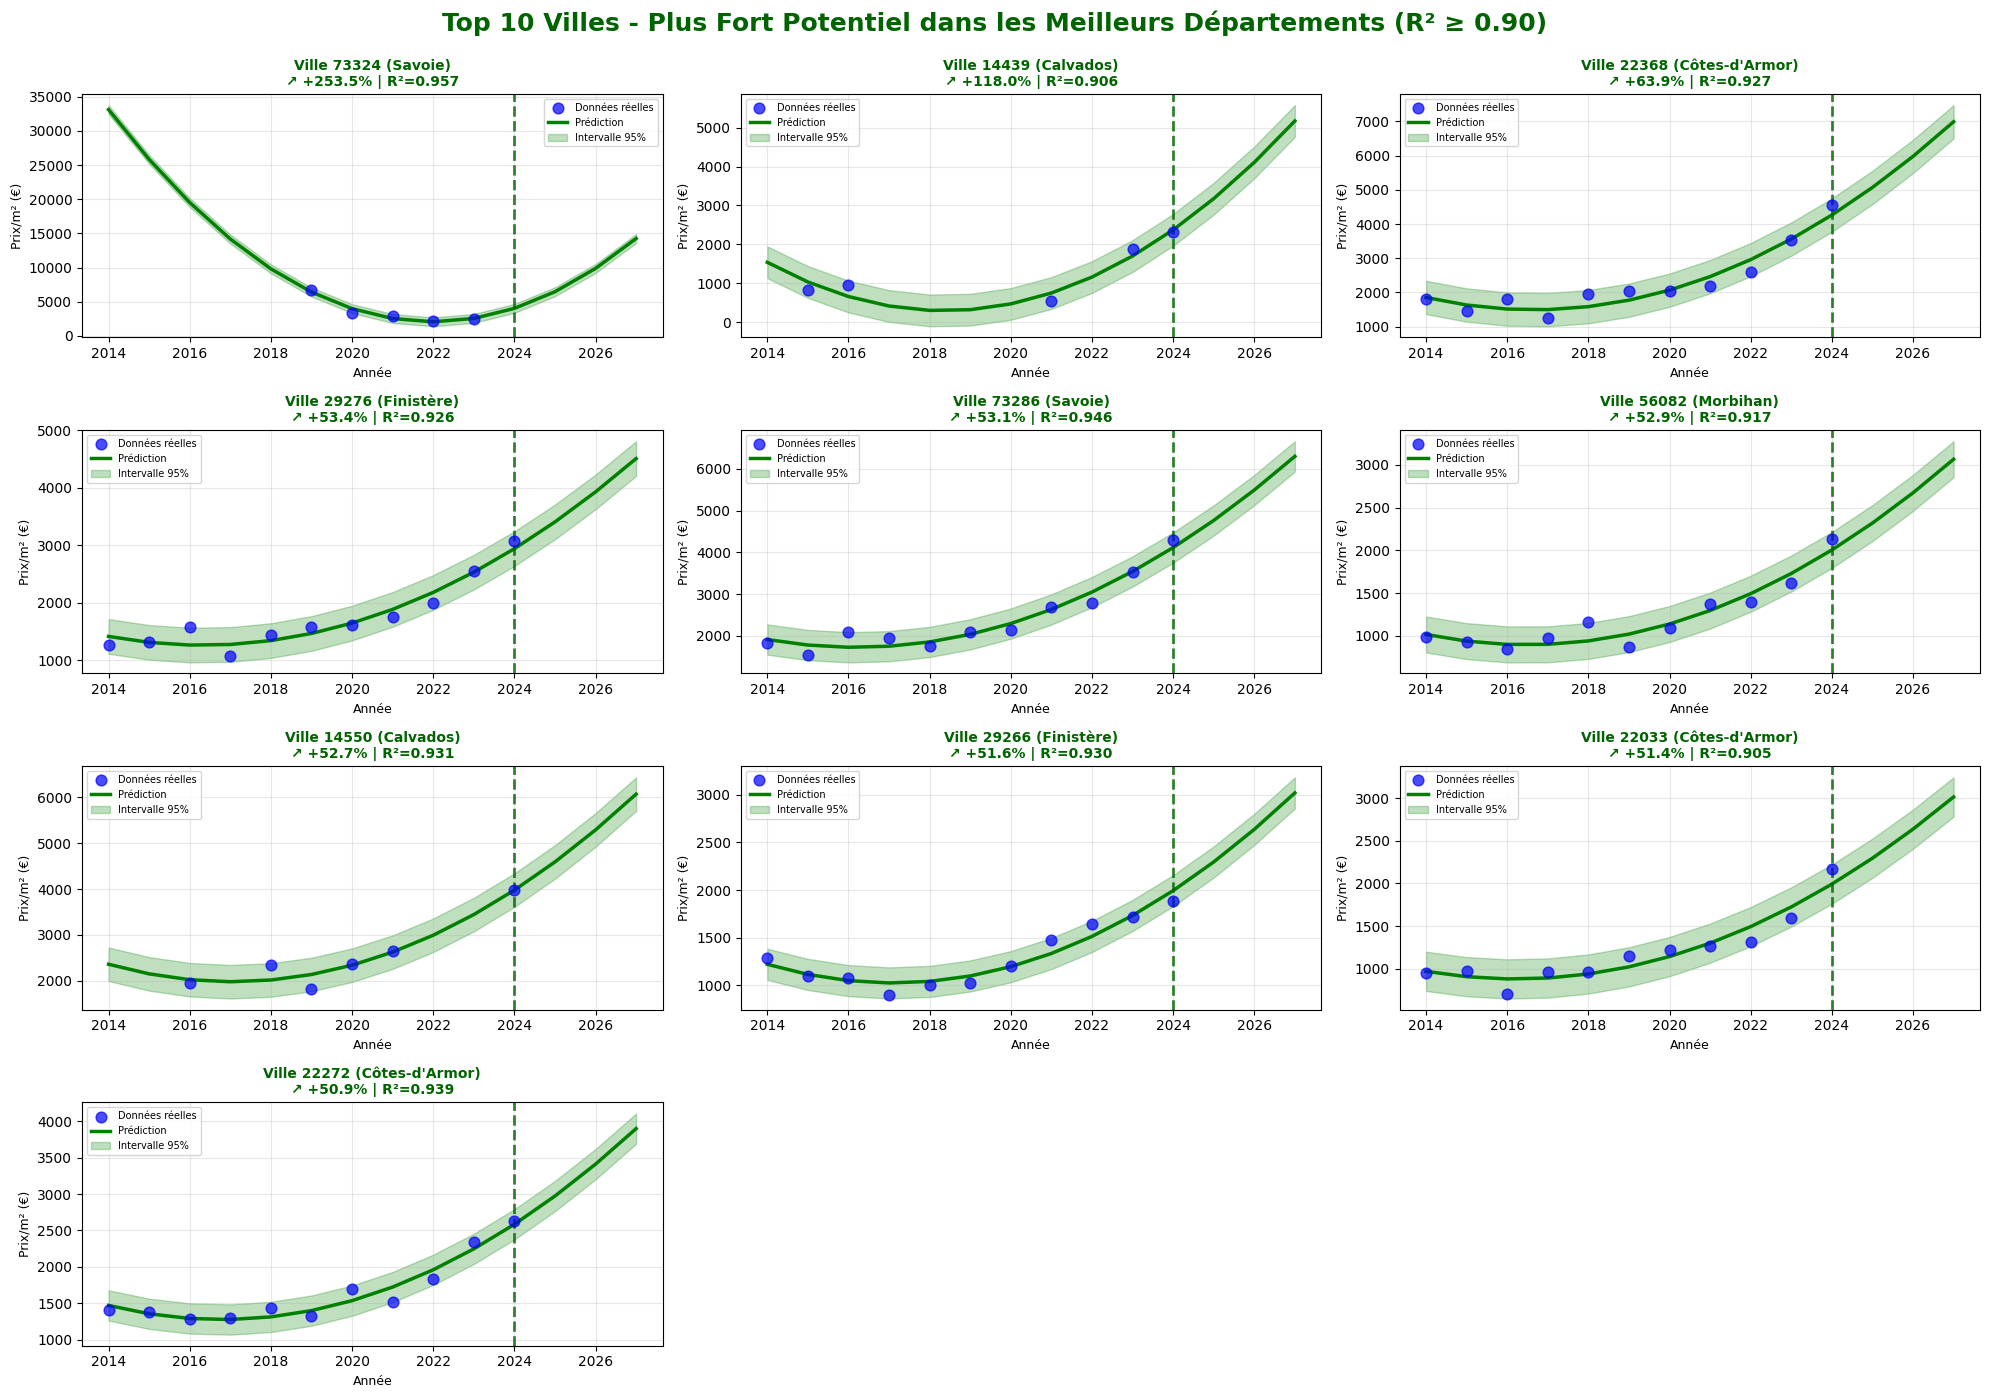


TOP 10 VILLES - PLUS FORT POTENTIEL D'AUGMENTATION DU PRIX AU M² (2024-2027)
Rang   Code INSEE   Département               Prix 2024    Prix 2027    Augmentation    % Hausse     Incertitude     R²         Années  
----------------------------------------------------------------------------------------------------------------------------------------------------------------
1      73324        Savoie (73)                   4036 €/m²     14266 €/m²  +   10231 €/m²   + 253.5 %     ±   657 €/m²      0.9573   5       
2      14439        Calvados (14)                 2372 €/m²      5171 €/m²  +    2800 €/m²   + 118.0 %     ±   408 €/m²      0.9060   5       
3      22368        Côtes-d'Armor (22)            4263 €/m²      6987 €/m²  +    2724 €/m²   +  63.9 %     ±   487 €/m²      0.9271   11      
4      29276        Finistère (29)                2938 €/m²      4507 €/m²  +    1569 €/m²   +  53.4 %     ±   302 €/m²      0.9258   11      
5      73286        Savoie (73)                   41

In [11]:
print("🔍 ÉTAPE 1 : Identification des 10 départements à plus fort potentiel d'augmentation\n")

predictions_dept_temp = {}
for dept in moyennes_dept['Departement'].unique():
    data_dept = moyennes_dept[moyennes_dept['Departement'] == dept]
    if len(data_dept) < 3:
        continue
    
    X = data_dept['annee'].values.reshape(-1, 1)
    y = data_dept['Prixm2Moyen'].values
    
    poly_features = PolynomialFeatures(degree=2)
    X_poly = poly_features.fit_transform(X)
    model_poly = LinearRegression()
    model_poly.fit(X_poly, y)
    
    X_futures_poly = poly_features.transform(annees_futures)
    predictions_poly = model_poly.predict(X_futures_poly)
    
    y_pred_train = model_poly.predict(X_poly)
    r2 = r2_score(y, y_pred_train)
    
    prix_2024 = predictions_poly[10]
    prix_2027 = predictions_poly[13]
    augmentation_pct = ((prix_2027 - prix_2024) / prix_2024) * 100
    
    predictions_dept_temp[dept] = {'augmentation_pct': augmentation_pct, 'r2': r2}

depts_fiables = {k: v for k, v in predictions_dept_temp.items() if v['r2'] >= 0.85}
top_10_depts = sorted(depts_fiables.items(), key=lambda x: x[1]['augmentation_pct'], reverse=True)[:10]
top_10_dept_codes = [dept for dept, _ in top_10_depts]

print(f"Départements sélectionnés : {', '.join(top_10_dept_codes)}\n")

print("🏙️ ÉTAPE 2 : Analyse des villes dans ces départements\n")

df_top_depts = df[df['Departement'].isin(top_10_dept_codes)].copy()
moyennes_villes = df_top_depts.groupby(['INSEE_COM', 'annee']).agg({
    'Prixm2Moyen': 'mean',
    'Departement': 'first'
}).reset_index()

predictions_villes = {}

for ville in moyennes_villes['INSEE_COM'].unique():
    data_ville = moyennes_villes[moyennes_villes['INSEE_COM'] == ville]
    if len(data_ville) < 5 or np.std(data_ville['Prixm2Moyen'].values) < 1:
        continue
    
    X = data_ville['annee'].values.reshape(-1, 1)
    y = data_ville['Prixm2Moyen'].values
    
    poly_features = PolynomialFeatures(degree=2)
    X_poly = poly_features.fit_transform(X)
    model_poly = LinearRegression()
    model_poly.fit(X_poly, y)
    
    X_futures_poly = poly_features.transform(annees_futures)
    predictions_poly = model_poly.predict(X_futures_poly)
    
    y_pred_train = model_poly.predict(X_poly)
    std_residus = np.std(y - y_pred_train)
    marge_erreur = 1.96 * std_residus
    r2 = r2_score(y, y_pred_train)
    
    prix_2024 = predictions_poly[10]
    prix_2027 = predictions_poly[13]
    augmentation_absolue = prix_2027 - prix_2024
    augmentation_pct = ((prix_2027 - prix_2024) / prix_2024) * 100
    
    predictions_villes[ville] = {
        'departement': data_ville['Departement'].iloc[0],
        'prix_2024': prix_2024,
        'prix_2027': prix_2027,
        'augmentation_absolue': augmentation_absolue,
        'augmentation_pct': augmentation_pct,
        'r2': r2,
        'incertitude': marge_erreur,
        'X': X,
        'y': y,
        'predictions_poly': predictions_poly,
        'predictions_min': predictions_poly - marge_erreur,
        'predictions_max': predictions_poly + marge_erreur,
        'nb_annees': len(data_ville)
    }

print(f"Villes analysées : {len(predictions_villes)}")

villes_fiables = {k: v for k, v in predictions_villes.items() if v['r2'] >= 0.90}
print(f"Villes fiables (R² ≥ 0.90) : {len(villes_fiables)}\n")

top_10_villes = sorted(villes_fiables.items(), key=lambda x: x[1]['augmentation_pct'], reverse=True)[:10]

print("📊 ÉTAPE 3 : Visualisation des 10 meilleures villes\n")

plt.figure(figsize=(20, 14))

for i, (ville_code, preds) in enumerate(top_10_villes, 1):
    plt.subplot(4, 3, i)
    plt.scatter(preds['X'], preds['y'], color='blue', s=60, alpha=0.7, label='Données réelles', zorder=3)
    plt.plot(annees_futures, preds['predictions_poly'], 'g-', linewidth=2.5, label='Prédiction', zorder=2)
    plt.fill_between(annees_futures.flatten(), preds['predictions_min'], preds['predictions_max'], 
                     alpha=0.25, color='green', label='Intervalle 95%', zorder=1)
    plt.axvline(x=2024, color='darkgreen', linestyle='--', linewidth=2, alpha=0.8)
    
    dept = preds['departement']
    nom_dept = noms_departements.get(dept, dept)
    
    plt.title(f'Ville {ville_code} ({nom_dept})\n↗ +{preds["augmentation_pct"]:.1f}% | R²={preds["r2"]:.3f}', 
              fontsize=10, fontweight='bold', color='darkgreen')
    plt.xlabel('Année', fontsize=9)
    plt.ylabel('Prix/m² (€)', fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=7, loc='best')

plt.suptitle('Top 10 Villes - Plus Fort Potentiel dans les Meilleurs Départements (R² ≥ 0.90)', 
             fontsize=18, fontweight='bold', y=0.995, color='darkgreen')
plt.tight_layout()
plt.show()

print("\n" + "="*160)
print("TOP 10 VILLES - PLUS FORT POTENTIEL D'AUGMENTATION DU PRIX AU M² (2024-2027)")
print("="*160)
print(f"{'Rang':<6} {'Code INSEE':<12} {'Département':<25} {'Prix 2024':<12} {'Prix 2027':<12} {'Augmentation':<15} {'% Hausse':<12} {'Incertitude':<15} {'R²':<10} {'Années':<8}")
print("-"*160)

for i, (ville_code, preds) in enumerate(top_10_villes, 1):
    dept = preds['departement']
    nom_dept = noms_departements.get(dept, dept)
    dept_complet = f"{nom_dept} ({dept})"
    
    print(f"{i:<6} {ville_code:<12} {dept_complet:<25} {preds['prix_2024']:>8.0f} €/m²  {preds['prix_2027']:>8.0f} €/m²  "
          f"+{preds['augmentation_absolue']:>8.0f} €/m²   +{preds['augmentation_pct']:>6.1f} %     "
          f"±{preds['incertitude']:>6.0f} €/m²      {preds['r2']:>6.4f}   {preds['nb_annees']:<8}")

print("="*160)

🔍 ÉTAPE 1 : Identification des 10 départements à plus fort potentiel d'augmentation

Départements sélectionnés : 56, 29, 22, 73, 05, 85, 35, 14, 43, 66

🏙️ ÉTAPE 2 : Analyse des villes avec critère nb_mutations ≥ 5

Villes avant filtrage : 2909
Villes après filtrage (nb_mutations ≥ 5) : 2094
Départements sélectionnés : 56, 29, 22, 73, 05, 85, 35, 14, 43, 66

🏙️ ÉTAPE 2 : Analyse des villes avec critère nb_mutations ≥ 5

Villes avant filtrage : 2909
Villes après filtrage (nb_mutations ≥ 5) : 2094
Villes analysées : 2094
Villes fiables (R² ≥ 0.90) : 295

📊 ÉTAPE 3 : Visualisation des 10 meilleures villes

Villes analysées : 2094
Villes fiables (R² ≥ 0.90) : 295

📊 ÉTAPE 3 : Visualisation des 10 meilleures villes



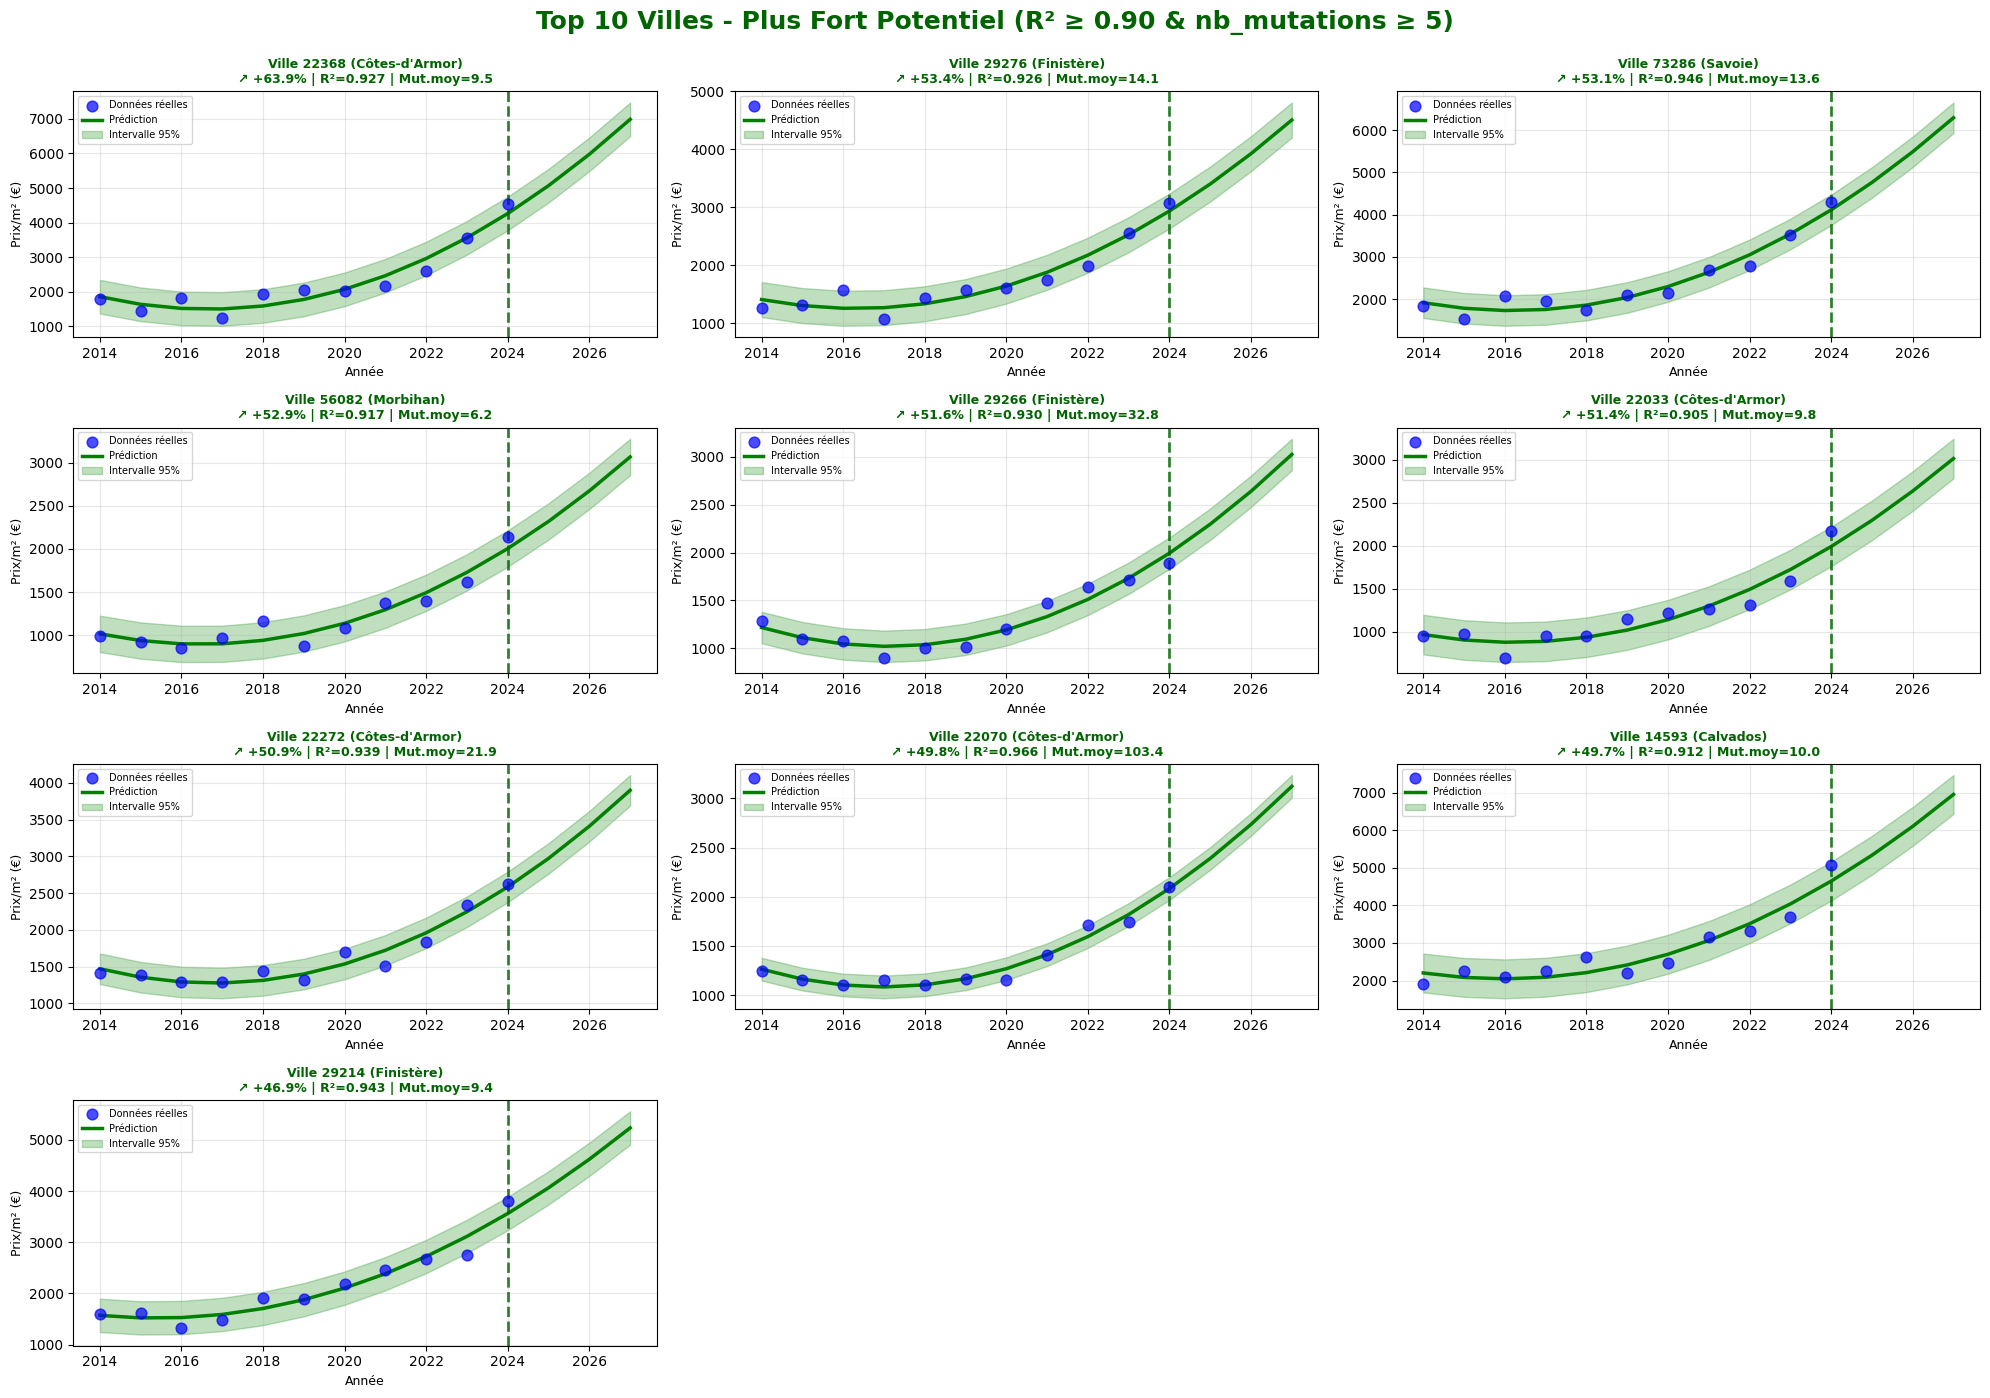


TOP 10 VILLES - PLUS FORT POTENTIEL D'AUGMENTATION DU PRIX AU M² (2024-2027)
Rang   Code INSEE   Département               Prix 2024    Prix 2027    Augmentation    % Hausse     Mut.moy    Incertitude     R²         Années  
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
1      22368        Côtes-d'Armor (22)            4263 €/m²      6987 €/m²  +    2724 €/m²   +  63.9 %        9.5     ±   487 €/m²      0.9271   11      
2      29276        Finistère (29)                2938 €/m²      4507 €/m²  +    1569 €/m²   +  53.4 %       14.1     ±   302 €/m²      0.9258   11      
3      73286        Savoie (73)                   4113 €/m²      6296 €/m²  +    2184 €/m²   +  53.1 %       13.6     ±   362 €/m²      0.9464   11      
4      56082        Morbihan (56)                 2004 €/m²      3065 €/m²  +    1061 €/m²   +  52.9 %        6.2     ±   211 €/m²      

In [12]:
print("🔍 ÉTAPE 1 : Identification des 10 départements à plus fort potentiel d'augmentation\n")

predictions_dept_temp = {}
for dept in moyennes_dept['Departement'].unique():
    data_dept = moyennes_dept[moyennes_dept['Departement'] == dept]
    if len(data_dept) < 3:
        continue
    
    X = data_dept['annee'].values.reshape(-1, 1)
    y = data_dept['Prixm2Moyen'].values
    
    poly_features = PolynomialFeatures(degree=2)
    X_poly = poly_features.fit_transform(X)
    model_poly = LinearRegression()
    model_poly.fit(X_poly, y)
    
    X_futures_poly = poly_features.transform(annees_futures)
    predictions_poly = model_poly.predict(X_futures_poly)
    
    y_pred_train = model_poly.predict(X_poly)
    r2 = r2_score(y, y_pred_train)
    
    prix_2024 = predictions_poly[10]
    prix_2027 = predictions_poly[13]
    augmentation_pct = ((prix_2027 - prix_2024) / prix_2024) * 100
    
    predictions_dept_temp[dept] = {'augmentation_pct': augmentation_pct, 'r2': r2}

depts_fiables = {k: v for k, v in predictions_dept_temp.items() if v['r2'] >= 0.85}
top_10_depts = sorted(depts_fiables.items(), key=lambda x: x[1]['augmentation_pct'], reverse=True)[:10]
top_10_dept_codes = [dept for dept, _ in top_10_depts]

print(f"Départements sélectionnés : {', '.join(top_10_dept_codes)}\n")

print("🏙️ ÉTAPE 2 : Analyse des villes avec critère nb_mutations ≥ 5\n")

df_top_depts = df[df['Departement'].isin(top_10_dept_codes)].copy()
moyennes_villes = df_top_depts.groupby(['INSEE_COM', 'annee']).agg({
    'Prixm2Moyen': 'mean',
    'nb_mutations': 'mean',
    'Departement': 'first'
}).reset_index()

mutations_moyennes_par_ville = moyennes_villes.groupby('INSEE_COM')['nb_mutations'].mean()
print(f"Villes avant filtrage : {len(moyennes_villes['INSEE_COM'].unique())}")

villes_avec_activite = mutations_moyennes_par_ville[mutations_moyennes_par_ville >= 5].index.tolist()
moyennes_villes = moyennes_villes[moyennes_villes['INSEE_COM'].isin(villes_avec_activite)]
print(f"Villes après filtrage (nb_mutations ≥ 5) : {len(moyennes_villes['INSEE_COM'].unique())}")

predictions_villes = {}

for ville in moyennes_villes['INSEE_COM'].unique():
    data_ville = moyennes_villes[moyennes_villes['INSEE_COM'] == ville]
    if len(data_ville) < 5 or np.std(data_ville['Prixm2Moyen'].values) < 1:
        continue
    
    X = data_ville['annee'].values.reshape(-1, 1)
    y = data_ville['Prixm2Moyen'].values
    
    poly_features = PolynomialFeatures(degree=2)
    X_poly = poly_features.fit_transform(X)
    model_poly = LinearRegression()
    model_poly.fit(X_poly, y)
    
    X_futures_poly = poly_features.transform(annees_futures)
    predictions_poly = model_poly.predict(X_futures_poly)
    
    y_pred_train = model_poly.predict(X_poly)
    std_residus = np.std(y - y_pred_train)
    marge_erreur = 1.96 * std_residus
    r2 = r2_score(y, y_pred_train)
    
    prix_2024 = predictions_poly[10]
    prix_2027 = predictions_poly[13]
    augmentation_absolue = prix_2027 - prix_2024
    augmentation_pct = ((prix_2027 - prix_2024) / prix_2024) * 100
    nb_mutations_moyen = mutations_moyennes_par_ville[ville]
    
    predictions_villes[ville] = {
        'departement': data_ville['Departement'].iloc[0],
        'prix_2024': prix_2024,
        'prix_2027': prix_2027,
        'augmentation_absolue': augmentation_absolue,
        'augmentation_pct': augmentation_pct,
        'r2': r2,
        'incertitude': marge_erreur,
        'nb_mutations_moyen': nb_mutations_moyen,
        'X': X,
        'y': y,
        'predictions_poly': predictions_poly,
        'predictions_min': predictions_poly - marge_erreur,
        'predictions_max': predictions_poly + marge_erreur,
        'nb_annees': len(data_ville)
    }

print(f"Villes analysées : {len(predictions_villes)}")

villes_fiables = {k: v for k, v in predictions_villes.items() if v['r2'] >= 0.90}
print(f"Villes fiables (R² ≥ 0.90) : {len(villes_fiables)}\n")

top_10_villes = sorted(villes_fiables.items(), key=lambda x: x[1]['augmentation_pct'], reverse=True)[:10]

print("📊 ÉTAPE 3 : Visualisation des 10 meilleures villes\n")

plt.figure(figsize=(20, 14))

for i, (ville_code, preds) in enumerate(top_10_villes, 1):
    plt.subplot(4, 3, i)
    plt.scatter(preds['X'], preds['y'], color='blue', s=60, alpha=0.7, label='Données réelles', zorder=3)
    plt.plot(annees_futures, preds['predictions_poly'], 'g-', linewidth=2.5, label='Prédiction', zorder=2)
    plt.fill_between(annees_futures.flatten(), preds['predictions_min'], preds['predictions_max'], 
                     alpha=0.25, color='green', label='Intervalle 95%', zorder=1)
    plt.axvline(x=2024, color='darkgreen', linestyle='--', linewidth=2, alpha=0.8)
    
    dept = preds['departement']
    nom_dept = noms_departements.get(dept, dept)
    
    plt.title(f'Ville {ville_code} ({nom_dept})\n↗ +{preds["augmentation_pct"]:.1f}% | R²={preds["r2"]:.3f} | Mut.moy={preds["nb_mutations_moyen"]:.1f}', 
              fontsize=9, fontweight='bold', color='darkgreen')
    plt.xlabel('Année', fontsize=9)
    plt.ylabel('Prix/m² (€)', fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=7, loc='best')

plt.suptitle('Top 10 Villes - Plus Fort Potentiel (R² ≥ 0.90 & nb_mutations ≥ 5)', 
             fontsize=18, fontweight='bold', y=0.995, color='darkgreen')
plt.tight_layout()
plt.show()

print("\n" + "="*175)
print("TOP 10 VILLES - PLUS FORT POTENTIEL D'AUGMENTATION DU PRIX AU M² (2024-2027)")
print("="*175)
print(f"{'Rang':<6} {'Code INSEE':<12} {'Département':<25} {'Prix 2024':<12} {'Prix 2027':<12} {'Augmentation':<15} {'% Hausse':<12} {'Mut.moy':<10} {'Incertitude':<15} {'R²':<10} {'Années':<8}")
print("-"*175)

for i, (ville_code, preds) in enumerate(top_10_villes, 1):
    dept = preds['departement']
    nom_dept = noms_departements.get(dept, dept)
    dept_complet = f"{nom_dept} ({dept})"
    
    print(f"{i:<6} {ville_code:<12} {dept_complet:<25} {preds['prix_2024']:>8.0f} €/m²  {preds['prix_2027']:>8.0f} €/m²  "
          f"+{preds['augmentation_absolue']:>8.0f} €/m²   +{preds['augmentation_pct']:>6.1f} %     "
          f"{preds['nb_mutations_moyen']:>6.1f}     "
          f"±{preds['incertitude']:>6.0f} €/m²      {preds['r2']:>6.4f}   {preds['nb_annees']:<8}")

print("="*175)

🔍 ANALYSE : TOP 10 VILLES AVEC LES PROJECTIONS LES PLUS PESSIMISTES (2024-2027)

📊 ÉTAPE 1 : Filtrage des communes avec ≥ 10 transactions en moyenne

Communes avec ≥ 10 transactions/an en moyenne : 9823

🔮 ÉTAPE 2 : Calcul des prédictions polynomiales (2024-2027)

Communes avec ≥ 10 transactions/an en moyenne : 9823

🔮 ÉTAPE 2 : Calcul des prédictions polynomiales (2024-2027)

Communes analysées : 9822

📉 ÉTAPE 3 : Sélection des villes avec projections pessimistes (R² ≥ 0.85)

Communes fiables (R² ≥ 0.85) : 1772
Top 10 des villes les plus pessimistes identifiées

📊 ÉTAPE 4 : Visualisation des 10 villes avec les pires projections

Communes analysées : 9822

📉 ÉTAPE 3 : Sélection des villes avec projections pessimistes (R² ≥ 0.85)

Communes fiables (R² ≥ 0.85) : 1772
Top 10 des villes les plus pessimistes identifiées

📊 ÉTAPE 4 : Visualisation des 10 villes avec les pires projections



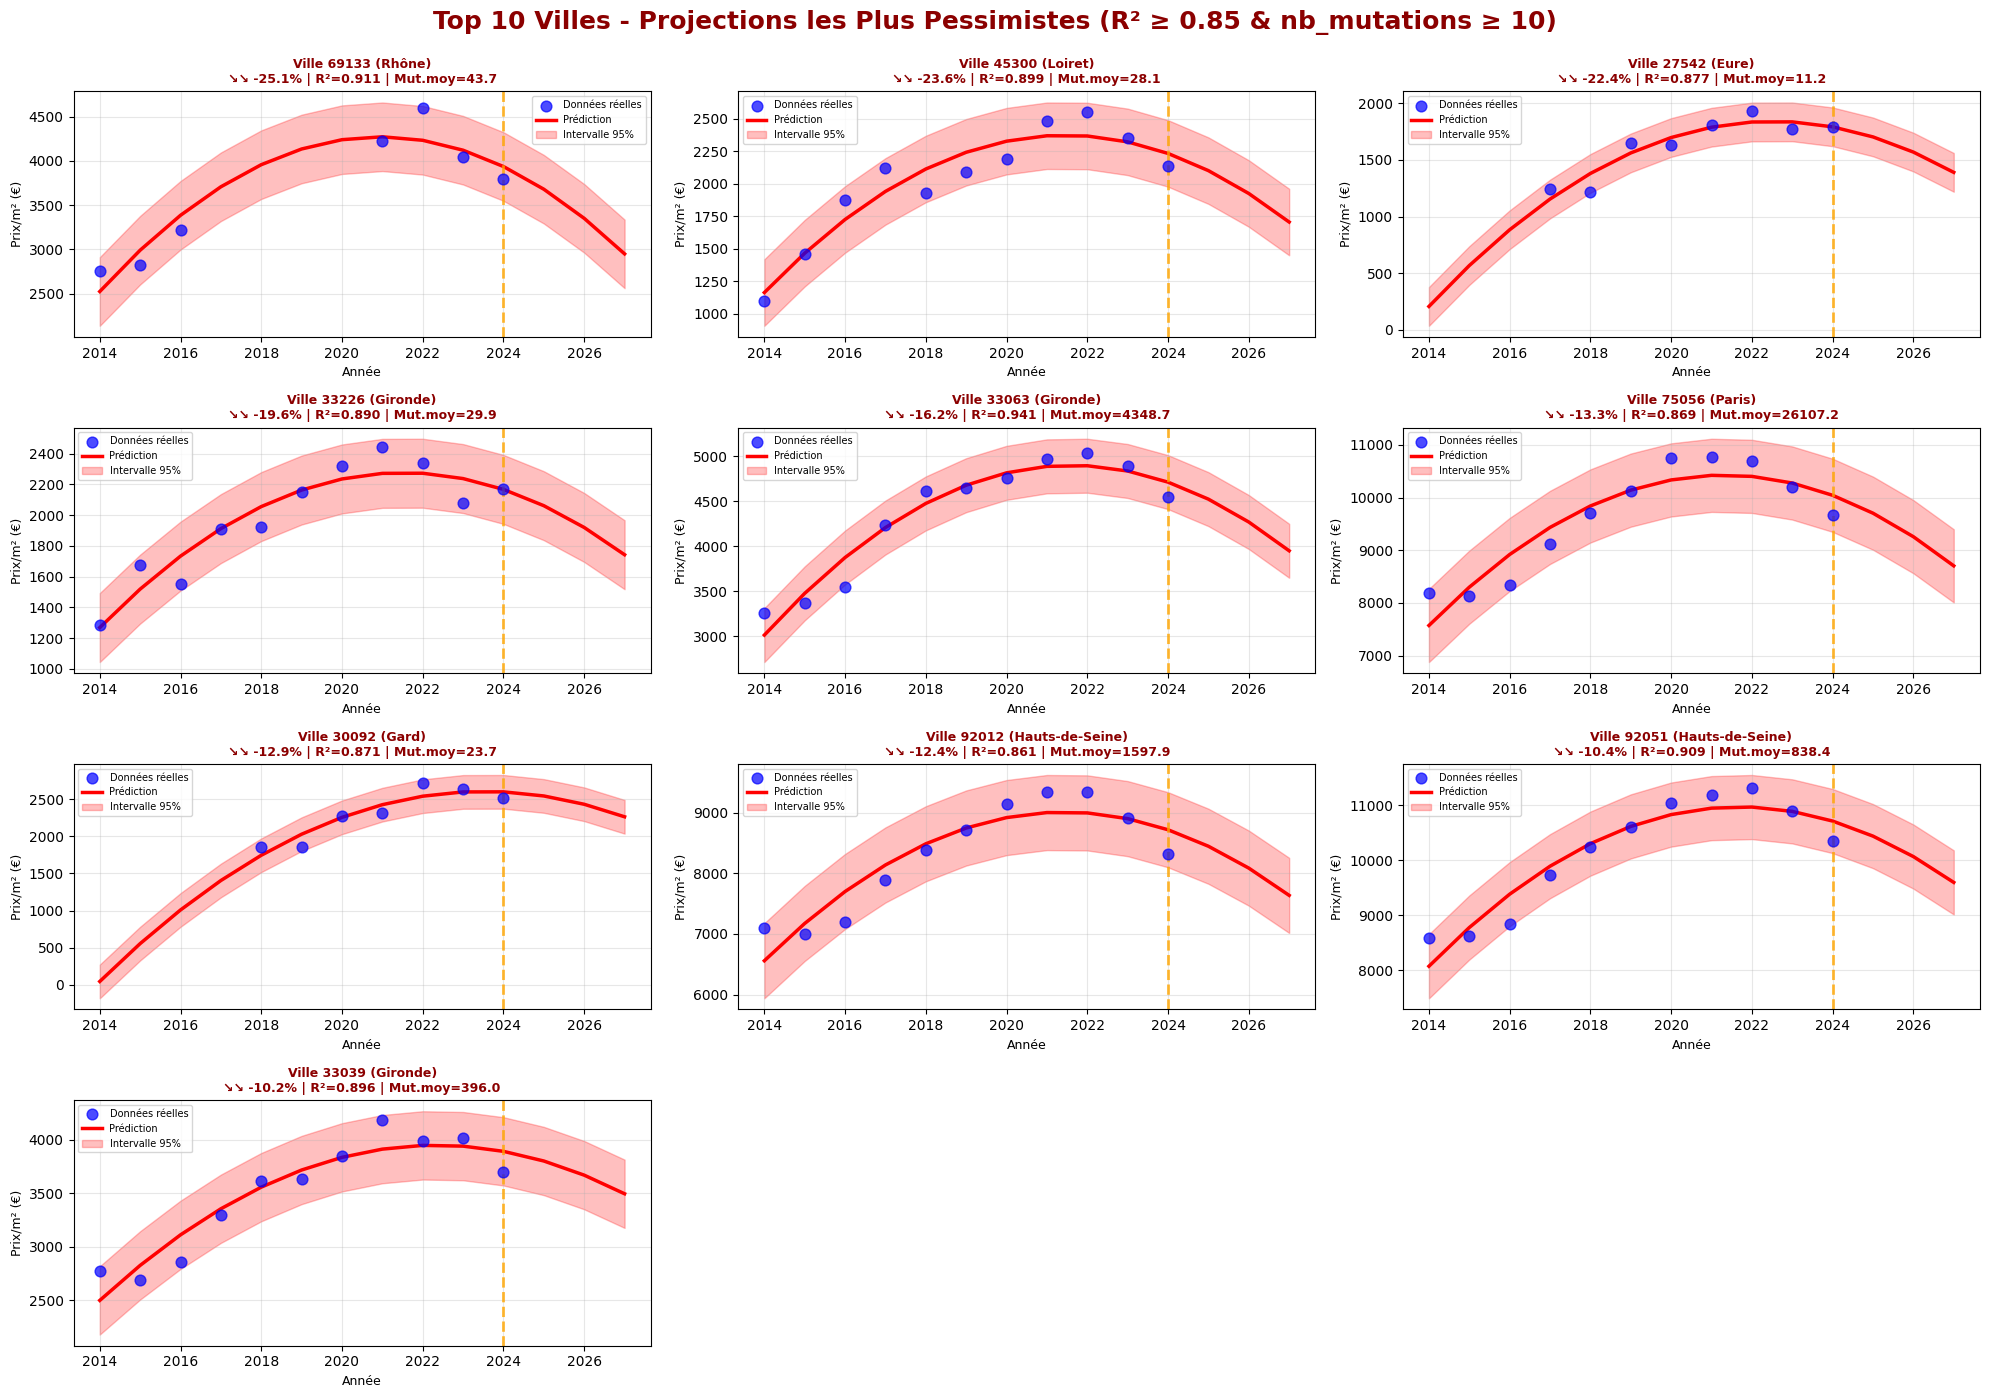


TOP 10 VILLES - PROJECTIONS LES PLUS PESSIMISTES DU PRIX AU M² (2024-2027)
Rang   Code INSEE   Département               Prix 2024    Prix 2027    Variation       % Évolution  Mut.moy    Incertitude     R²         Années  
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
1      69133        Rhône (69)                    3937 €/m²      2950 €/m²      -986 €/m²    -25.1 %       43.7     ±   387 €/m²      0.9111   7       
2      45300        Loiret (45)                   2233 €/m²      1706 €/m²      -527 €/m²    -23.6 %       28.1     ±   256 €/m²      0.8989   11      
3      27542        Eure (27)                     1792 €/m²      1390 €/m²      -402 €/m²    -22.4 %       11.2     ±   171 €/m²      0.8768   8       
4      33226        Gironde (33)                  2168 €/m²      1742 €/m²      -425 €/m²    -19.6 %       29.9     ±   224 €/m²      0.8896   1

In [13]:
print("="*100)
print("🔍 ANALYSE : TOP 10 VILLES AVEC LES PROJECTIONS LES PLUS PESSIMISTES (2024-2027)")
print("="*100)

print("\n📊 ÉTAPE 1 : Filtrage des communes avec ≥ 10 transactions en moyenne\n")

moyennes_communes = df.groupby(['INSEE_COM', 'annee']).agg({
    'Prixm2Moyen': 'mean',
    'nb_mutations': 'sum',
    'Departement': 'first'
}).reset_index()

transactions_moyennes = moyennes_communes.groupby('INSEE_COM').agg({
    'nb_mutations': 'mean',
    'Departement': 'first'
}).reset_index()

communes_actives = transactions_moyennes[transactions_moyennes['nb_mutations'] >= 10]['INSEE_COM']
print(f"Communes avec ≥ 10 transactions/an en moyenne : {len(communes_actives)}\n")

moyennes_communes_filtrees = moyennes_communes[moyennes_communes['INSEE_COM'].isin(communes_actives)]

print("🔮 ÉTAPE 2 : Calcul des prédictions polynomiales (2024-2027)\n")

predictions_communes = {}

for commune in communes_actives:
    data_commune = moyennes_communes_filtrees[moyennes_communes_filtrees['INSEE_COM'] == commune]
    if len(data_commune) < 5 or np.std(data_commune['Prixm2Moyen'].values) < 1:
        continue
    
    X = data_commune['annee'].values.reshape(-1, 1)
    y = data_commune['Prixm2Moyen'].values
    
    poly_features = PolynomialFeatures(degree=2)
    X_poly = poly_features.fit_transform(X)
    model_poly = LinearRegression()
    model_poly.fit(X_poly, y)
    
    X_futures_poly = poly_features.transform(annees_futures)
    predictions_poly = model_poly.predict(X_futures_poly)
    
    y_pred_train = model_poly.predict(X_poly)
    std_residus = np.std(y - y_pred_train)
    marge_erreur = 1.96 * std_residus
    r2 = r2_score(y, y_pred_train)
    
    prix_2024 = predictions_poly[10]
    prix_2027 = predictions_poly[13]
    variation_absolue = prix_2027 - prix_2024
    variation_pct = ((prix_2027 - prix_2024) / prix_2024) * 100
    nb_mut_moyen = transactions_moyennes[transactions_moyennes['INSEE_COM'] == commune]['nb_mutations'].iloc[0]
    
    predictions_communes[commune] = {
        'departement': data_commune['Departement'].iloc[0],
        'prix_2024': prix_2024,
        'prix_2027': prix_2027,
        'variation_absolue': variation_absolue,
        'variation_pct': variation_pct,
        'r2': r2,
        'incertitude': marge_erreur,
        'nb_mutations_moyen': nb_mut_moyen,
        'X': X,
        'y': y,
        'predictions_poly': predictions_poly,
        'predictions_min': predictions_poly - marge_erreur,
        'predictions_max': predictions_poly + marge_erreur,
        'nb_annees': len(data_commune)
    }

print(f"Communes analysées : {len(predictions_communes)}")

print("\n📉 ÉTAPE 3 : Sélection des villes avec projections pessimistes (R² ≥ 0.85)\n")

communes_fiables = {k: v for k, v in predictions_communes.items() if v['r2'] >= 0.85}
print(f"Communes fiables (R² ≥ 0.85) : {len(communes_fiables)}")

top_10_pessimistes = sorted(communes_fiables.items(), key=lambda x: x[1]['variation_pct'], reverse=False)[:10]
print(f"Top 10 des villes les plus pessimistes identifiées\n")

print("📊 ÉTAPE 4 : Visualisation des 10 villes avec les pires projections\n")

plt.figure(figsize=(20, 14))

for i, (commune_code, preds) in enumerate(top_10_pessimistes, 1):
    plt.subplot(4, 3, i)
    plt.scatter(preds['X'], preds['y'], color='blue', s=60, alpha=0.7, label='Données réelles', zorder=3)
    plt.plot(annees_futures, preds['predictions_poly'], 'r-', linewidth=2.5, label='Prédiction', zorder=2)
    plt.fill_between(annees_futures.flatten(), preds['predictions_min'], preds['predictions_max'], 
                     alpha=0.25, color='red', label='Intervalle 95%', zorder=1)
    plt.axvline(x=2024, color='orange', linestyle='--', linewidth=2, alpha=0.8)
    
    dept = preds['departement']
    nom_dept = noms_departements.get(dept, dept)
    
    symbole = '↘↘' if preds['variation_pct'] < -2 else ('↘' if preds['variation_pct'] < 0 else '→')
    couleur = 'darkred' if preds['variation_pct'] < -2 else ('red' if preds['variation_pct'] < 0 else 'darkorange')
    
    plt.title(f'Ville {commune_code} ({nom_dept})\n{symbole} {preds["variation_pct"]:.1f}% | R²={preds["r2"]:.3f} | Mut.moy={preds["nb_mutations_moyen"]:.1f}', 
              fontsize=9, fontweight='bold', color=couleur)
    plt.xlabel('Année', fontsize=9)
    plt.ylabel('Prix/m² (€)', fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=7, loc='best')

plt.suptitle('Top 10 Villes - Projections les Plus Pessimistes (R² ≥ 0.85 & nb_mutations ≥ 10)', 
             fontsize=18, fontweight='bold', y=0.995, color='darkred')
plt.tight_layout()
plt.show()

print("\n" + "="*175)
print("TOP 10 VILLES - PROJECTIONS LES PLUS PESSIMISTES DU PRIX AU M² (2024-2027)")
print("="*175)
print(f"{'Rang':<6} {'Code INSEE':<12} {'Département':<25} {'Prix 2024':<12} {'Prix 2027':<12} {'Variation':<15} {'% Évolution':<12} {'Mut.moy':<10} {'Incertitude':<15} {'R²':<10} {'Années':<8}")
print("-"*175)

for i, (commune_code, preds) in enumerate(top_10_pessimistes, 1):
    dept = preds['departement']
    nom_dept = noms_departements.get(dept, dept)
    dept_complet = f"{nom_dept} ({dept})"
    
    variation_sign = '+' if preds['variation_absolue'] >= 0 else ''
    pourcent_sign = '+' if preds['variation_pct'] >= 0 else ''
    
    print(f"{i:<6} {commune_code:<12} {dept_complet:<25} {preds['prix_2024']:>8.0f} €/m²  {preds['prix_2027']:>8.0f} €/m²  "
          f"{variation_sign}{preds['variation_absolue']:>8.0f} €/m²   {pourcent_sign}{preds['variation_pct']:>6.1f} %     "
          f"{preds['nb_mutations_moyen']:>6.1f}     "
          f"±{preds['incertitude']:>6.0f} €/m²      {preds['r2']:>6.4f}   {preds['nb_annees']:<8}")

print("="*175)

🤖 MODÈLE DE PRÉDICTION DU PRIX AU M² - FRANCE ENTIÈRE (2014-2027)

📂 ÉTAPE 1 : Chargement et exploration des données

Lignes totales : 320,598
Communes : 33,147
Lignes totales : 320,598
Communes : 33,147
Lignes après nettoyage : 320,598 (100.0%)

📊 Données nationales : 11 années (2014-2024)

⚙️ ÉTAPE 2 : Création des features

Features créées : Annee_idx, Moyennes mobiles, Croissance, Volatilité, Lags

🔀 ÉTAPE 3 : Séparation Train / Validation / Test

Train : 7 années | Val : 2 années | Test : 2 années

🧠 ÉTAPE 4 : Entraînement des modèles

  ✅ Régression Linéaire
  ✅ Ridge
  ✅ Lasso
Lignes après nettoyage : 320,598 (100.0%)

📊 Données nationales : 11 années (2014-2024)

⚙️ ÉTAPE 2 : Création des features

Features créées : Annee_idx, Moyennes mobiles, Croissance, Volatilité, Lags

🔀 ÉTAPE 3 : Séparation Train / Validation / Test

Train : 7 années | Val : 2 années | Test : 2 années

🧠 ÉTAPE 4 : Entraînement des modèles

  ✅ Régression Linéaire
  ✅ Ridge
  ✅ Lasso
  ✅ Random Forest
  ✅ 

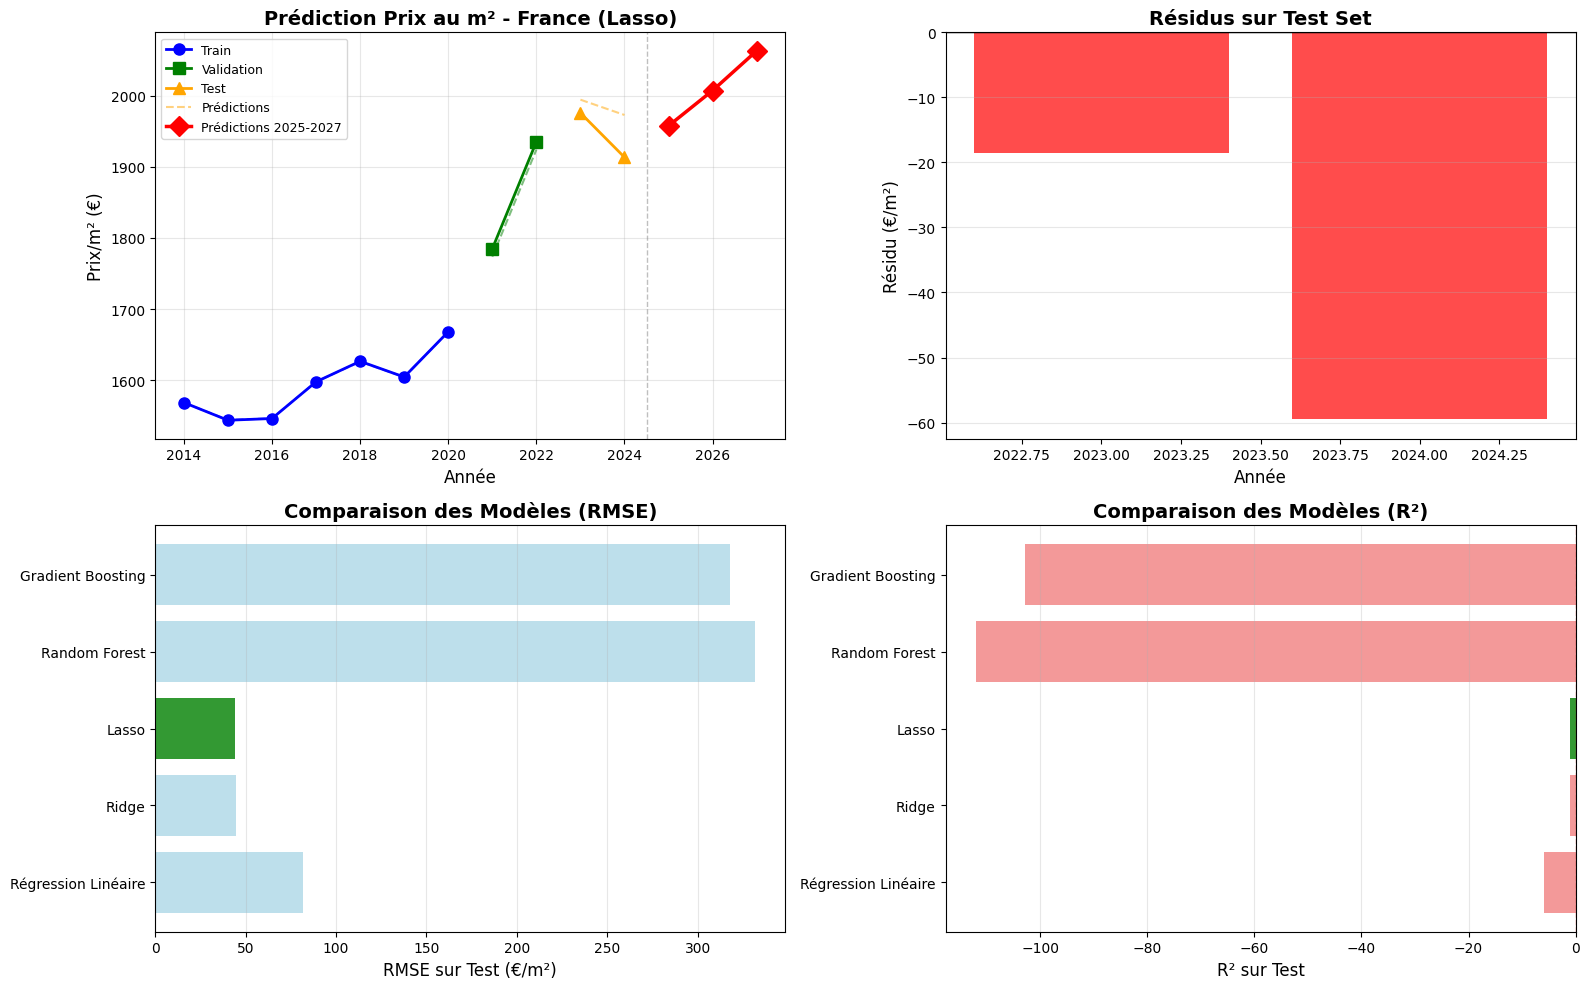


✅ ANALYSE TERMINÉE


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("="*100)
print("🤖 MODÈLE DE PRÉDICTION DU PRIX AU M² - FRANCE ENTIÈRE (2014-2027)")
print("="*100)

print("\n📂 ÉTAPE 1 : Chargement et exploration des données\n")

df_model = pd.read_csv(r'C:\Users\Clement\OneDrive\Bureau\data imo\code\dvf.csv', sep=',', skipinitialspace=True)
df_model.columns = df_model.columns.str.strip()

print(f"Lignes totales : {len(df_model):,}")
print(f"Communes : {df_model['INSEE_COM'].nunique():,}")

df_clean = df_model.dropna(subset=['annee', 'Prixm2Moyen', 'nb_mutations']).copy()
df_clean = df_clean[(df_clean['Prixm2Moyen'] > 100) & (df_clean['Prixm2Moyen'] < 20000)]
df_clean = df_clean[df_clean['nb_mutations'] > 0]

print(f"Lignes après nettoyage : {len(df_clean):,} ({len(df_clean)/len(df_model)*100:.1f}%)")

df_national = df_clean.groupby('annee').agg({
    'Prixm2Moyen': 'mean',
    'SurfaceMoy': 'mean',
    'nb_mutations': 'sum',
    'NbMaisons': 'sum',
    'NbApparts': 'sum',
    'PrixMoyen': 'mean'
}).reset_index()

df_national['PropMaisons'] = df_national['NbMaisons'] / (df_national['NbMaisons'] + df_national['NbApparts'])
df_national['PropApparts'] = df_national['NbApparts'] / (df_national['NbMaisons'] + df_national['NbApparts'])

print(f"\n📊 Données nationales : {len(df_national)} années ({df_national['annee'].min():.0f}-{df_national['annee'].max():.0f})")

print("\n⚙️ ÉTAPE 2 : Création des features\n")

df_national['Annee_idx'] = df_national['annee'] - df_national['annee'].min()
df_national['Prix_MA3'] = df_national['Prixm2Moyen'].rolling(window=3, min_periods=1).mean()
df_national['Prix_MA5'] = df_national['Prixm2Moyen'].rolling(window=5, min_periods=1).mean()
df_national['Prix_Growth'] = df_national['Prixm2Moyen'].pct_change().fillna(0) * 100
df_national['Prix_Volatility'] = df_national['Prixm2Moyen'].rolling(window=3, min_periods=1).std().fillna(0)
df_national['Prix_Lag1'] = df_national['Prixm2Moyen'].shift(1).fillna(df_national['Prixm2Moyen'].iloc[0])
df_national['Prix_Lag2'] = df_national['Prixm2Moyen'].shift(2).fillna(df_national['Prixm2Moyen'].iloc[0])
df_national['Mutations_Growth'] = df_national['nb_mutations'].pct_change().fillna(0) * 100
df_national = df_national.fillna(0)

print("Features créées : Annee_idx, Moyennes mobiles, Croissance, Volatilité, Lags")

print("\n🔀 ÉTAPE 3 : Séparation Train / Validation / Test\n")

feature_columns = ['Annee_idx', 'SurfaceMoy', 'nb_mutations', 'PropMaisons', 
                   'Prix_MA3', 'Prix_Growth', 'Prix_Volatility', 'Prix_Lag1', 'Mutations_Growth']

X = df_national[feature_columns].values
y = df_national['Prixm2Moyen'].values
annees = df_national['annee'].values

n_years = len(df_national)
train_size = max(int(n_years * 0.64), n_years - 4)
val_size = max(int(n_years * 0.18), 2)

X_train = X[:train_size]
y_train = y[:train_size]
annees_train = annees[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]
annees_val = annees[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]
annees_test = annees[train_size+val_size:]

print(f"Train : {len(annees_train)} années | Val : {len(annees_val)} années | Test : {len(annees_test)} années")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val) if len(X_val) > 0 else np.array([])
X_test_scaled = scaler.transform(X_test) if len(X_test) > 0 else np.array([])

print("\n🧠 ÉTAPE 4 : Entraînement des modèles\n")

models = {
    'Régression Linéaire': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1, max_iter=10000),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
}

results = {}

for name, model in models.items():
    try:
        model.fit(X_train_scaled, y_train)
        
        y_train_pred = model.predict(X_train_scaled)
        y_val_pred = model.predict(X_val_scaled) if len(X_val_scaled) > 0 else np.array([])
        y_test_pred = model.predict(X_test_scaled) if len(X_test_scaled) > 0 else np.array([])
        
        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
        train_r2 = r2_score(y_train, y_train_pred)
        
        val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred)) if len(y_val_pred) > 0 else np.nan
        val_r2 = r2_score(y_val, y_val_pred) if len(y_val_pred) > 0 else np.nan
        
        test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred)) if len(y_test_pred) > 0 else np.nan
        test_r2 = r2_score(y_test, y_test_pred) if len(y_test_pred) > 0 else np.nan
        test_mae = mean_absolute_error(y_test, y_test_pred) if len(y_test_pred) > 0 else np.nan
        
        results[name] = {
            'model': model,
            'train_rmse': train_rmse,
            'train_r2': train_r2,
            'val_rmse': val_rmse,
            'val_r2': val_r2,
            'test_rmse': test_rmse,
            'test_mae': test_mae,
            'test_r2': test_r2,
            'y_train_pred': y_train_pred,
            'y_val_pred': y_val_pred,
            'y_test_pred': y_test_pred
        }
        print(f"  ✅ {name}")
    except Exception as e:
        print(f"  ❌ {name} : {str(e)}")

print("\n📊 ÉTAPE 5 : Comparaison des performances\n")
print("="*130)
print(f"{'Modèle':<20} {'Train RMSE':<12} {'Train R²':<10} {'Val RMSE':<12} {'Val R²':<10} {'Test RMSE':<12} {'Test R²':<10}")
print("-"*130)

for name, res in results.items():
    val_rmse_str = f"{res['val_rmse']:>8.2f} €/m²" if not np.isnan(res['val_rmse']) else "    N/A"
    val_r2_str = f"{res['val_r2']:>7.4f}" if not np.isnan(res['val_r2']) else "  N/A"
    test_rmse_str = f"{res['test_rmse']:>8.2f} €/m²" if not np.isnan(res['test_rmse']) else "    N/A"
    test_r2_str = f"{res['test_r2']:>7.4f}" if not np.isnan(res['test_r2']) else "  N/A"
    
    print(f"{name:<20} {res['train_rmse']:>8.2f} €/m²  {res['train_r2']:>7.4f}   "
          f"{val_rmse_str}  {val_r2_str}   {test_rmse_str}  {test_r2_str}")

print("="*130)

best_model_name = min(results.keys(), key=lambda k: results[k]['val_rmse'] if not np.isnan(results[k]['val_rmse']) else results[k]['train_rmse'])
print(f"\n🏆 MEILLEUR MODÈLE : {best_model_name}")
best_model_info = results[best_model_name]

print(f"  → RMSE train : {best_model_info['train_rmse']:.2f} €/m²")
print(f"  → R² train : {best_model_info['train_r2']:.4f}")

print("\n🔮 ÉTAPE 6 : Prédictions 2025-2027\n")

future_years = np.array([2025, 2026, 2027])
last_row = df_national.iloc[-1]
future_data = []

for i, year in enumerate(future_years):
    if i == 0:
        prev_prix = df_national.iloc[-1]['Prixm2Moyen']
        prev_prix_lag1 = df_national.iloc[-1]['Prixm2Moyen']
        prev_prix_lag2 = df_national.iloc[-2]['Prixm2Moyen']
    else:
        prev_prix = future_data[i-1]['prix_pred']
        prev_prix_lag1 = prev_prix
        prev_prix_lag2 = df_national.iloc[-1]['Prixm2Moyen'] if i == 1 else future_data[i-2]['prix_pred']
    
    annee_idx = year - df_national['annee'].min()
    future_features = np.array([[
        annee_idx,
        last_row['SurfaceMoy'],
        last_row['nb_mutations'],
        last_row['PropMaisons'],
        prev_prix,
        0,
        df_national['Prix_Volatility'].iloc[-1],
        prev_prix_lag1,
        0
    ]])
    
    future_features_scaled = scaler.transform(future_features)
    prix_pred = best_model_info['model'].predict(future_features_scaled)[0]
    
    future_data.append({'annee': year, 'prix_pred': prix_pred})

print("Prédictions du prix au m² moyen en France :")
print("-" * 50)
for item in future_data:
    print(f"  {item['annee']:.0f} : {item['prix_pred']:.2f} €/m²")

prix_2024 = df_national.iloc[-1]['Prixm2Moyen']
prix_2027 = future_data[-1]['prix_pred']
variation_pct = ((prix_2027 - prix_2024) / prix_2024) * 100

print(f"\n📈 Variation 2024-2027 : {variation_pct:+.2f}% ({prix_2027 - prix_2024:+.2f} €/m²)")

print("\n📉 ÉTAPE 7 : Visualisation\n")

plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
plt.plot(annees_train, y_train, 'o-', color='blue', linewidth=2, markersize=8, label='Train')
if len(annees_val) > 0:
    plt.plot(annees_val, y_val, 's-', color='green', linewidth=2, markersize=8, label='Validation')
if len(annees_test) > 0:
    plt.plot(annees_test, y_test, '^-', color='orange', linewidth=2, markersize=8, label='Test')

plt.plot(annees_train, best_model_info['y_train_pred'], '--', color='blue', alpha=0.5, linewidth=1.5)
if len(best_model_info['y_val_pred']) > 0:
    plt.plot(annees_val, best_model_info['y_val_pred'], '--', color='green', alpha=0.5, linewidth=1.5)
if len(best_model_info['y_test_pred']) > 0:
    plt.plot(annees_test, best_model_info['y_test_pred'], '--', color='orange', alpha=0.5, linewidth=1.5, label='Prédictions')

future_years_arr = [item['annee'] for item in future_data]
future_prices = [item['prix_pred'] for item in future_data]
plt.plot(future_years_arr, future_prices, 'D-', color='red', linewidth=2.5, markersize=10, label='Prédictions 2025-2027')

plt.axvline(x=2024.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.title(f'Prédiction Prix au m² - France ({best_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Année', fontsize=12)
plt.ylabel('Prix/m² (€)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9, loc='best')

if len(annees_test) > 0:
    plt.subplot(2, 2, 2)
    residuals_test = y_test - best_model_info['y_test_pred']
    plt.bar(annees_test, residuals_test, color=['green' if r > 0 else 'red' for r in residuals_test], alpha=0.7)
    plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
    plt.title('Résidus sur Test Set', fontsize=14, fontweight='bold')
    plt.xlabel('Année', fontsize=12)
    plt.ylabel('Résidu (€/m²)', fontsize=12)
    plt.grid(True, alpha=0.3, axis='y')

plt.subplot(2, 2, 3)
model_names = list(results.keys())
test_rmses = [results[name]['test_rmse'] for name in model_names]
colors_rmse = ['green' if name == best_model_name else 'lightblue' for name in model_names]
plt.barh(model_names, test_rmses, color=colors_rmse, alpha=0.8)
plt.xlabel('RMSE sur Test (€/m²)', fontsize=12)
plt.title('Comparaison des Modèles (RMSE)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')

plt.subplot(2, 2, 4)
test_r2s = [results[name]['test_r2'] for name in model_names]
colors_r2 = ['green' if name == best_model_name else 'lightcoral' for name in model_names]
plt.barh(model_names, test_r2s, color=colors_r2, alpha=0.8)
plt.xlabel('R² sur Test', fontsize=12)
plt.title('Comparaison des Modèles (R²)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

print("\n" + "="*100)
print("✅ ANALYSE TERMINÉE")
print("="*100)

In [4]:
# 🔍 DIAGNOSTIC : Vérifier les valeurs de R²
print("="*80)
print("DIAGNOSTIC DES VALEURS R²")
print("="*80)
print(f"\ntest_r2s = {test_r2s}")
print(f"\nmodel_names = {model_names}")
print(f"\ntype(test_r2s[0]) = {type(test_r2s[0])}")

# Vérifier s'il y a des NaN
print(f"\nNombre de NaN dans test_r2s : {sum([1 for x in test_r2s if np.isnan(x)])}")
print(f"Nombre de valeurs valides : {sum([1 for x in test_r2s if not np.isnan(x)])}")

# Afficher détails par modèle
print("\nDétails par modèle :")
for name in model_names:
    print(f"  {name}: test_r2 = {results[name]['test_r2']}")

DIAGNOSTIC DES VALEURS R²

test_r2s = [-5.860270316671805, -1.0399838381489355, -0.9944954664411787, -112.07144315310215, -102.77672059300303]

model_names = ['Régression Linéaire', 'Ridge (L2)', 'Lasso (L1)', 'Random Forest', 'Gradient Boosting']

type(test_r2s[0]) = <class 'float'>

Nombre de NaN dans test_r2s : 0
Nombre de valeurs valides : 5

Détails par modèle :
  Régression Linéaire: test_r2 = -5.860270316671805
  Ridge (L2): test_r2 = -1.0399838381489355
  Lasso (L1): test_r2 = -0.9944954664411787
  Random Forest: test_r2 = -112.07144315310215
  Gradient Boosting: test_r2 = -102.77672059300303
